# 🧬 Cross-Modal Attention Fusion Network (CMAFN) for Parkinson's Disease Detection

## Multimodal Fusion: Handwriting + Speech Audio

**🎯 Novel Architecture: Cross-Modal Transformer Attention + Gated Multimodal Unit**

### Key Innovations (Beyond Existing IEEE Papers):
- ✅ **Cross-Modal Transformer Attention** — Each modality attends to the other (not found in IEEE PD fusion papers)
- ✅ **Gated Multimodal Unit (GMU)** — Learnable gates adaptively weight modality contributions
- ✅ **Modality Dropout Training** — Randomly drops one modality during training for robustness
- ✅ **Uncertainty-Aware Prediction** — Monte Carlo dropout for confidence estimation
- ✅ **Pre-trained Modality Encoders** — EfficientNet-B4+CBAM (handwriting) + XLS-R+SE (audio)
- ✅ **Cross-Modal Contrastive Loss** — Aligns modality embeddings in shared space

### How This Differs from IEEE Fusion Papers:
| IEEE Approach | Limitation | Our CMAFN |
|---|---|---|
| Simple late fusion (voting/averaging) | No cross-modal interaction | Cross-modal transformer learns inter-modality dependencies |
| Early fusion (feature concatenation) | Equal weight to all features | GMU adaptively weights each modality per sample |
| Single-modal only | Misses complementary biomarkers | Combines motor (handwriting) + vocal (speech) biomarkers |
| Fixed fusion weights | Can't adapt to input quality | Gated attention adapts weights per sample |
| No missing modality handling | Fails if one input missing | Modality dropout + learned default tokens |

### 📁 Datasets:
- **Handwriting**: Spiral/wave images (Healthy vs Parkinson) — EfficientNet-B4 + SPP + CBAM features
- **Speech Audio**: Italian Parkinson's Voice & Speech (831 recordings) — XLS-R 300M + SE Attention features

### 📊 Individual Model Baselines:
- Handwriting alone: **87.55% accuracy, 0.9354 AUC**
- Speech alone: **93.62% accuracy, 0.9661 AUC**
- **Fusion target: >95% accuracy, >0.98 AUC**

---
**Runs on Kaggle GPU (T4/P100) — Enable GPU: Settings → Accelerator → GPU**

In [1]:
# ============================================
# 📦 CELL 1: Install Dependencies
# ============================================

%pip install -q timm albumentations transformers datasets
%pip install -q librosa soundfile praat-parselmouth
%pip install -q xgboost lightgbm scikit-learn
%pip install -q grad-cam efficientnet-pytorch
%pip install -q torchaudio

print("✅ All dependencies installed!")

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 4.9 MB/s eta 0:00:0000:010:01mm
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 93.5 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ All dependencies installed!


In [2]:
# ============================================
# 📚 CELL 2: Import Libraries
# ============================================

import os
import sys
import gc
import json
import random
import warnings
import subprocess
from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm.auto import tqdm

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
import timm

# Audio
import librosa
import soundfile as sf

try:
    import parselmouth
    from parselmouth.praat import call
    PARSELMOUTH_AVAILABLE = True
except ImportError:
    PARSELMOUTH_AVAILABLE = False

# XLS-R
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

# Image Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# ============= Environment Detection =============
IN_KAGGLE = os.path.exists('/kaggle/working')
IN_COLAB = 'google.colab' in sys.modules
IN_LOCAL = not IN_KAGGLE and not IN_COLAB

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"🖥️  Environment: {'Kaggle' if IN_KAGGLE else 'Colab' if IN_COLAB else 'Local'}")
print(f"🔧 Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  WARNING: No GPU detected! Training will be very slow.")
    if IN_KAGGLE:
        print("   → Go to Settings → Accelerator → select 'GPU T4 x2' or 'GPU P100' and restart.")
    elif IN_COLAB:
        print("   → Go to Runtime → Change runtime type → select 'T4 GPU'.")
print(f"📦 PyTorch: {torch.__version__}")

# ============= AMP Compatibility =============
# Handle both PyTorch 2.x and 1.x AMP APIs
try:
    _test_scaler = torch.amp.GradScaler('cuda')
    USE_NEW_AMP_API = True
    del _test_scaler
except (TypeError, AttributeError):
    USE_NEW_AMP_API = False
print(f"⚡ AMP API: {'torch.amp (2.x)' if USE_NEW_AMP_API else 'torch.cuda.amp (1.x)'}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

🖥️  Environment: Kaggle
🔧 Device: cuda
🎮 GPU: Tesla P100-PCIE-16GB
💾 GPU Memory: 17.1 GB
📦 PyTorch: 2.8.0+cu126
⚡ AMP API: torch.amp (2.x)


In [3]:
# ============================================
# ⚙️ CELL 3: Configuration
# ============================================

@dataclass
class FusionConfig:
    """Configuration for Cross-Modal Attention Fusion Network."""
    
    # === Paths ===
    checkpoint_dir: str = "./checkpoints_fusion"
    
    # === Handwriting Model ===
    hw_image_size: int = 336
    hw_feature_dim: int = 512  # Output of handwriting feature extractor
    
    # === Audio Model ===
    sample_rate: int = 16000
    max_audio_length: int = 8  # seconds
    n_mfcc: int = 40
    n_mels: int = 128
    n_fft: int = 2048
    hop_length: int = 512
    use_delta_mfcc: bool = True
    use_spectral_contrast: bool = True
    use_chroma: bool = True
    use_tonnetz: bool = True
    wav2vec2_model_name: str = "facebook/wav2vec2-xls-r-300m"
    wav2vec2_embed_dim: int = 1024
    freeze_wav2vec2: bool = True
    audio_feature_dim: int = 512  # Output of audio feature extractor (after projection)
    
    # === Fusion Architecture ===
    fusion_embed_dim: int = 256       # Shared embedding dimension
    n_attention_heads: int = 8        # Cross-modal transformer heads
    n_transformer_layers: int = 2     # Number of cross-attention layers
    gmu_hidden_dim: int = 128         # Gated Multimodal Unit hidden dim
    fusion_dropout: float = 0.5       # Dropout in fusion layers
    modality_dropout: float = 0.25    # Probability of dropping one modality during training
    
    # === Training ===
    batch_size: int = 16
    num_epochs: int = 100
    learning_rate: float = 1e-4       # Base LR for CosineAnnealingLR (no OneCycleLR peak)
    weight_decay: float = 0.05        # L2 regularization
    warmup_epochs: int = 5
    patience: int = 10                # Early stopping patience per fold
    
    # === Loss ===
    focal_alpha: float = 0.5
    focal_gamma: float = 2.0
    label_smoothing: float = 0.1      # Soft targets prevent overconfidence
    contrastive_weight: float = 0.3   # Cross-modal alignment strength
    
    # === Augmentation ===
    use_mixup: bool = True
    mixup_alpha: float = 0.3
    spec_augment: bool = True
    freq_mask_param: int = 15
    time_mask_param: int = 25
    
    # === MC Dropout (Uncertainty) ===
    mc_dropout_samples: int = 10
    
    # === Misc ===
    seed: int = 42
    num_workers: int = 0 if os.path.exists('/kaggle/working') else 2  # 0 on Kaggle for stability
    n_folds: int = 5  # K-fold cross-validation


# AudioConfig is needed to unpickle the pre-trained audio checkpoint (best_audio_model.pth)
@dataclass
class AudioConfig:
    """Configuration used when training the standalone audio model."""
    checkpoint_dir: str = "./checkpoints_audio"
    sample_rate: int = 16000
    max_audio_length: int = 8
    n_mfcc: int = 40
    n_mels: int = 128
    n_fft: int = 2048
    hop_length: int = 512
    use_delta_mfcc: bool = True
    use_spectral_contrast: bool = True
    use_chroma: bool = True
    use_tonnetz: bool = True
    wav2vec2_model_name: str = "facebook/wav2vec2-xls-r-300m"
    wav2vec2_embed_dim: int = 1024
    freeze_wav2vec2: bool = True
    hidden_dim: int = 256
    dropout: float = 0.4
    batch_size: int = 16
    num_epochs: int = 100
    learning_rate: float = 1e-4
    weight_decay: float = 0.03
    n_folds: int = 5
    focal_alpha: float = 0.75
    focal_gamma: float = 3.0
    label_smoothing: float = 0.05
    optimize_threshold: bool = True
    patience: int = 20
    use_augmentation: bool = True
    time_stretch_rate: Tuple[float, float] = (0.85, 1.15)
    pitch_shift_steps: int = 3
    noise_factor: float = 0.008
    spec_augment: bool = True
    freq_mask_param: int = 15
    time_mask_param: int = 25
    use_mixup: bool = True
    mixup_alpha: float = 0.4
    seed: int = 42
    num_workers: int = 0


config = FusionConfig()
os.makedirs(config.checkpoint_dir, exist_ok=True)

# Set seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.seed)

print("✅ Fusion Configuration loaded!")
print(f"   Fusion embed dim: {config.fusion_embed_dim}")
print(f"   Cross-modal attention heads: {config.n_attention_heads}")
print(f"   Transformer layers: {config.n_transformer_layers}")
print(f"   Modality dropout: {config.modality_dropout}")
print(f"   Fusion dropout: {config.fusion_dropout}")
print(f"   Weight decay: {config.weight_decay}")
print(f"   Label smoothing: {config.label_smoothing}")
print(f"   Contrastive loss weight: {config.contrastive_weight}")
print(f"   Early stopping patience: {config.patience}")
print(f"   K-fold CV: {config.n_folds} folds")
print(f"   LR schedule: CosineAnnealingLR (lr={config.learning_rate})")
print(f"   MC Dropout samples: {config.mc_dropout_samples}")
print(f"   num_workers: {config.num_workers}")

✅ Fusion Configuration loaded!
   Fusion embed dim: 256
   Cross-modal attention heads: 8
   Transformer layers: 2
   Modality dropout: 0.25
   Fusion dropout: 0.5
   Weight decay: 0.05
   Label smoothing: 0.1
   Contrastive loss weight: 0.3
   Early stopping patience: 10
   K-fold CV: 5 folds
   LR schedule: CosineAnnealingLR (lr=0.0001)
   MC Dropout samples: 10
   num_workers: 0


In [4]:
# ============================================
# 📂 CELL 4: Dataset Paths Setup (Kaggle/Colab/Local)
# ============================================

GITHUB_REPO = "https://github.com/Tvenkatathanuj/SDP.git"
REPO_NAME = "SDP"

def is_lfs_pointer(filepath):
    """Check if a file is a Git LFS pointer (text) instead of actual binary."""
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            first_line = f.readline()
            return first_line.startswith('version https://git-lfs')
    except (UnicodeDecodeError, OSError):
        return False  # Binary file = real data, not a pointer

def download_lfs_file_via_curl(repo_url, file_path, dest_path):
    """Download a single file from GitHub using curl (bypasses LFS)."""
    raw_url = repo_url.replace('.git', '') + f'/raw/main/{file_path}'
    print(f"   ⬇️ Downloading {file_path} from GitHub...")
    result = subprocess.run(
        ['curl', '-L', '-o', str(dest_path), raw_url],
        capture_output=True, text=True, timeout=600
    )
    if result.returncode == 0 and dest_path.exists() and dest_path.stat().st_size > 1000:
        if not is_lfs_pointer(str(dest_path)):
            print(f"   ✅ Downloaded {file_path} ({dest_path.stat().st_size / 1e6:.1f} MB)")
            return True
    print(f"   ⚠️ curl download may have failed for {file_path}")
    return False

def verify_images_readable(directory, n_samples=10):
    """Check if images in a directory are real image files (not LFS pointers)."""
    pngs = sorted(directory.glob('*.png'))
    if not pngs:
        return 0, 0
    step = max(1, len(pngs) // n_samples)
    samples = pngs[::step][:n_samples]
    n_ok = 0
    for p in samples:
        if p.stat().st_size > 500 and not is_lfs_pointer(str(p)):
            n_ok += 1
    return n_ok, len(samples)

# =================================================================
# STEP 0: Check for handwriting data in Kaggle Dataset inputs
# =================================================================
KAGGLE_HW_INPUT_PATH = None

if IN_KAGGLE:
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        for input_dir in sorted(kaggle_input.iterdir()):
            if not input_dir.is_dir():
                continue
            for candidate in [
                input_dir,
                input_dir / 'Dataset' / 'Dataset',
                input_dir / 'handwritten dataset' / 'Dataset' / 'Dataset',
                input_dir / 'handwritten_dataset' / 'Dataset' / 'Dataset',
                input_dir / 'Dataset',
            ]:
                healthy = candidate / 'Healthy'
                parkinson = candidate / 'Parkinson'
                if healthy.exists() and parkinson.exists():
                    n_ok, n_total = verify_images_readable(healthy, 5)
                    if n_ok == n_total and n_total > 0:
                        KAGGLE_HW_INPUT_PATH = candidate
                        print(f"✅ Found handwriting dataset in Kaggle input: {input_dir.name}")
                        print(f"   Path: {candidate}")
                        break
            if KAGGLE_HW_INPUT_PATH:
                break

# =================================================================
# STEP 1-2: Clone repo and download model files
# =================================================================
if IN_COLAB or IN_KAGGLE:
    # Step 1: Clone repository (images + audio are regular git objects now)
    if not Path(REPO_NAME).exists():
        print(f"📥 Cloning repository from {GITHUB_REPO}...")
        print("   ⏳ This includes datasets (images + audio) — may take a few minutes...")
        # Clone WITHOUT LFS smudge to avoid budget errors on .pth files
        env = os.environ.copy()
        env['GIT_LFS_SKIP_SMUDGE'] = '1'
        result = subprocess.run(
            ['git', 'clone', GITHUB_REPO],
            capture_output=True, text=True, timeout=600, env=env
        )
        if result.returncode == 0 or Path(REPO_NAME).exists():
            print("✅ Repository cloned successfully!")
        else:
            print(f"❌ Clone failed: {result.stderr}")
    else:
        print("✅ Repository already exists")

    DATASET_ROOT = Path(REPO_NAME)

    # Step 2: Download pre-trained model files directly via curl
    # (Avoids Git LFS budget limits — .pth files are the only LFS-tracked files)
    print("\n🔍 Downloading pre-trained model files...")
    os.makedirs(str(DATASET_ROOT / 'checkpoints'), exist_ok=True)
    model_files = [
        ('handwriting_parkinsons_model_final(2).pth', 'handwriting_parkinsons_model_final(2).pth'),
        ('best_handwriting_model(2).pth', 'best_handwriting_model(2).pth'),
        ('checkpoints/best_audio_model.pth', 'checkpoints/best_audio_model.pth'),
    ]
    for file_rel, file_path in model_files:
        full_path = DATASET_ROOT / file_rel
        if full_path.exists() and full_path.stat().st_size > 10000 and not is_lfs_pointer(str(full_path)):
            print(f"   ✅ {file_rel} already OK ({full_path.stat().st_size / 1e6:.1f} MB)")
        else:
            download_lfs_file_via_curl(GITHUB_REPO, file_path, full_path)

else:
    DATASET_ROOT = Path('.')

# =================================================================
# STEP 3: Set final paths
# =================================================================

# Handwriting: prefer Kaggle Dataset input if available
if KAGGLE_HW_INPUT_PATH:
    HW_DATA_PATH = KAGGLE_HW_INPUT_PATH
else:
    HW_DATA_PATH = DATASET_ROOT / 'handwritten dataset' / 'Dataset' / 'Dataset'
HW_HEALTHY_PATH = HW_DATA_PATH / 'Healthy'
HW_PARKINSON_PATH = HW_DATA_PATH / 'Parkinson'

# Audio (always from cloned repo — .wav files are regular git objects)
ITALIAN_PD_DIR = DATASET_ROOT / "Italian Parkinson's Voice and speech"

# Pre-trained Models
HW_MODEL_PATH = DATASET_ROOT / 'handwriting_parkinsons_model_final(2).pth'
AUDIO_MODEL_PATH = DATASET_ROOT / 'checkpoints' / 'best_audio_model.pth'
if not HW_MODEL_PATH.exists():
    HW_MODEL_PATH = DATASET_ROOT / 'best_handwriting_model(2).pth'

# =================================================================
# STEP 4: Verify handwriting images are readable
# =================================================================
if HW_HEALTHY_PATH.exists():
    n_ok, n_total = verify_images_readable(HW_HEALTHY_PATH, 10)
    if n_ok < n_total:
        print(f"\n{'='*70}")
        print(f"❌ HANDWRITING IMAGES ARE NOT READABLE!")
        print(f"{'='*70}")
        print(f"   {n_total - n_ok}/{n_total} sampled images failed verification.")
        print(f"   Try deleting the SDP folder and re-cloning:")
        print(f"   !rm -rf SDP")
        print(f"   Then re-run all cells from the top.")
        print(f"{'='*70}")
    else:
        print(f"   ✅ Handwriting images verified: {n_ok}/{n_total} samples are real image data")

print(f"\n📁 Dataset Root: {DATASET_ROOT.absolute()}")
print(f"   🖊️  HW Dataset Path:     {HW_DATA_PATH}")
print(f"   🖊️  Handwriting Dataset: {'✅ Found' if HW_DATA_PATH.exists() else '❌ Missing'}")
print(f"   🎤 Audio Dataset:       {'✅ Found' if ITALIAN_PD_DIR.exists() else '❌ Missing'}")
print(f"   🧠 HW Pre-trained:      {'✅ Found' if HW_MODEL_PATH.exists() else '❌ Missing'} ({HW_MODEL_PATH.name})")
print(f"   🧠 Audio Pre-trained:   {'✅ Found' if AUDIO_MODEL_PATH.exists() else '❌ Missing'} ({AUDIO_MODEL_PATH.name})")
if KAGGLE_HW_INPUT_PATH:
    print(f"   📦 Using Kaggle Dataset for handwriting images (reliable!)")

📥 Cloning repository from https://github.com/Tvenkatathanuj/SDP.git...
   ⏳ This includes datasets (images + audio) — may take a few minutes...
✅ Repository cloned successfully!

🔍 Downloading pre-trained model files...
   ⬇️ Downloading handwriting_parkinsons_model_final(2).pth from GitHub...
   ✅ Downloaded handwriting_parkinsons_model_final(2).pth (106.9 MB)
   ⬇️ Downloading best_handwriting_model(2).pth from GitHub...
   ✅ Downloaded best_handwriting_model(2).pth (146.7 MB)
   ⬇️ Downloading checkpoints/best_audio_model.pth from GitHub...
   ✅ Downloaded checkpoints/best_audio_model.pth (5.4 MB)
   ✅ Handwriting images verified: 10/10 samples are real image data

📁 Dataset Root: /kaggle/working/SDP
   🖊️  HW Dataset Path:     SDP/handwritten dataset/Dataset/Dataset
   🖊️  Handwriting Dataset: ✅ Found
   🎤 Audio Dataset:       ✅ Found
   🧠 HW Pre-trained:      ✅ Found (handwriting_parkinsons_model_final(2).pth)
   🧠 Audio Pre-trained:   ✅ Found (best_audio_model.pth)


---
## 🏗️ Part 1: Modality-Specific Feature Extractors

Re-define both pre-trained model architectures so we can load their weights and extract features.

In [5]:
# ============================================
# 🖊️ CELL 5: Handwriting Model Architecture (from pre-trained)
# ============================================

class ChannelAttention(nn.Module):
    """CBAM Channel Attention Module"""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    """CBAM Spatial Attention Module"""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    """Convolutional Block Attention Module"""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x


class SpatialPyramidPooling(nn.Module):
    """Spatial Pyramid Pooling for multi-scale features"""
    def __init__(self, pool_sizes=[1, 2, 4]):
        super().__init__()
        self.pool_sizes = pool_sizes

    def forward(self, x):
        batch_size, _channels, _, _ = x.size()
        pools = []
        for pool_size in self.pool_sizes:
            pool = F.adaptive_avg_pool2d(x, (pool_size, pool_size))
            pool = pool.view(batch_size, -1)
            pools.append(pool)
        return torch.cat(pools, dim=1)


class HandwritingParkinsonsModel(nn.Module):
    """EfficientNet-B4 + SPP + CBAM + Multi-Head Classifier"""
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b4', pretrained=pretrained, features_only=True)
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            features = self.backbone(dummy_input)
            feature_dim = features[-1].shape[1]
        self.cbam = CBAM(feature_dim)
        self.spp = SpatialPyramidPooling(pool_sizes=[1, 2, 4])
        spp_out_dim = feature_dim * (1 + 4 + 16)
        self.classifier = nn.Sequential(
            nn.Linear(spp_out_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.6),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        self.feature_extractor = nn.Sequential(
            nn.Linear(spp_out_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, return_features=False):
        features = self.backbone(x)
        x = features[-1]
        x = self.cbam(x)
        x = self.spp(x)
        x = x.view(x.size(0), -1)
        if return_features:
            return self.feature_extractor(x)
        return self.classifier(x)


print("✅ Handwriting model architecture defined (EfficientNet-B4 + SPP + CBAM)")

✅ Handwriting model architecture defined (EfficientNet-B4 + SPP + CBAM)


In [6]:
# ============================================
# 🎤 CELL 6: Audio Model Architecture (from pre-trained)
# ============================================

class Wav2VecAudioModel(nn.Module):
    """4-Path Fusion with SE Attention: XLS-R + CNN + MFCC + Acoustic."""

    def __init__(self, n_mfcc_features=160, n_acoustic_features=39,
                 wav2vec2_embed_dim=1024, hidden_dim=256, dropout=0.4):
        super().__init__()
        self.n_mfcc_features = n_mfcc_features
        self.n_acoustic_features = n_acoustic_features
        self.w2v_dim = wav2vec2_embed_dim

        # Path 1: XLS-R embedding MLP (1024 → 256)
        self.w2v_encoder = nn.Sequential(
            nn.Linear(wav2vec2_embed_dim, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout * 0.5)
        )

        # Path 2: CNN for Mel-Spectrograms
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(), nn.AdaptiveAvgPool2d((2, 2)), nn.Dropout2d(0.3)
        )
        cnn_output_dim = 128 * 2 * 2  # 512

        # Path 3: MFCC MLP
        self.mfcc_encoder = nn.Sequential(
            nn.Linear(n_mfcc_features, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout * 0.5)
        )

        # Path 4: Acoustic MLP
        self.acoustic_encoder = nn.Sequential(
            nn.Linear(n_acoustic_features, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64), nn.ReLU()
        )

        # Fusion: 256 + 512 + 128 + 64 = 960
        fusion_dim = 256 + cnn_output_dim + 128 + 64
        se_reduction = 8
        self.se = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim // se_reduction),
            nn.ReLU(),
            nn.Linear(fusion_dim // se_reduction, fusion_dim),
            nn.Sigmoid()
        )

        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout * 0.7),
            nn.Linear(128, 2)
        )

        # Feature extractor (for fusion model) — outputs 512-dim
        self.audio_feature_extractor = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.BatchNorm1d(512), nn.ReLU()
        )

    def forward(self, mel_spec, mfcc, acoustic, w2v_emb, return_features=False):
        single_sample = mel_spec.size(0) == 1 and self.training
        if single_sample:
            self.eval()

        x_w2v = self.w2v_encoder(w2v_emb)
        x_cnn = self.conv1(mel_spec)
        x_cnn = self.conv2(x_cnn)
        x_cnn = self.conv3(x_cnn)
        x_cnn = x_cnn.view(x_cnn.size(0), -1)
        x_mfcc = self.mfcc_encoder(mfcc)
        x_acoustic = self.acoustic_encoder(acoustic)

        x_fused = torch.cat([x_w2v, x_cnn, x_mfcc, x_acoustic], dim=1)
        se_weights = self.se(x_fused)
        x_fused = x_fused * se_weights

        if return_features:
            if single_sample:
                self.train()
            return self.audio_feature_extractor(x_fused)

        logits = self.fusion(x_fused)
        if single_sample:
            self.train()
        return {'logits': logits}


print("✅ Audio model architecture defined (XLS-R + CNN + MFCC + Acoustic + SE)")

✅ Audio model architecture defined (XLS-R + CNN + MFCC + Acoustic + SE)


In [7]:
# ============================================
# 🎤 CELL 7: Audio Feature Extraction Utilities
# ============================================

class Wav2Vec2Extractor:
    """Extract XLS-R multilingual embeddings from raw audio (frozen)."""

    def __init__(self, model_name, _embed_dim=None, device=None, freeze=True):
        self.device = device or DEVICE
        print(f"   Loading XLS-R: {model_name}...")
        self.feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
        self.model = Wav2Vec2Model.from_pretrained(model_name)
        self.model.eval().to(self.device)
        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False
        print(f"   ✅ XLS-R loaded ({sum(p.numel() for p in self.model.parameters()) / 1e6:.1f}M params)")

    @torch.no_grad()
    def extract_embedding(self, waveform: np.ndarray) -> np.ndarray:
        inputs = self.feature_extractor(
            waveform, sampling_rate=16000, return_tensors="pt", padding=True
        )
        input_values = inputs.input_values.to(self.device)
        outputs = self.model(input_values)
        embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy()
        return embedding


class AudioFeatureExtractor:
    """Extract MFCC + Voice Quality + Spectral features."""

    def __init__(self, sr=16000, n_mfcc=40, n_mels=128, n_fft=2048, hop_length=512,
                 use_delta=True, use_contrast=True, use_chroma=True, use_tonnetz=True):
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.use_delta = use_delta
        self.use_contrast = use_contrast
        self.use_chroma = use_chroma
        self.use_tonnetz = use_tonnetz
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0
        )

    def extract_mfcc(self, waveform):
        mfcc = librosa.feature.mfcc(y=waveform, sr=self.sr, n_mfcc=self.n_mfcc)
        features = np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])
        if self.use_delta:
            delta_mfcc = librosa.feature.delta(mfcc, order=1)
            features = np.concatenate([
                features, np.mean(delta_mfcc, axis=1), np.std(delta_mfcc, axis=1)
            ])
        return features

    def extract_voice_quality(self, waveform):
        features = {}
        if PARSELMOUTH_AVAILABLE and len(waveform) > self.sr * 0.5:
            try:
                sound = parselmouth.Sound(waveform, sampling_frequency=self.sr)
                pitch = sound.to_pitch(time_step=0.01)
                features['mean_pitch'] = call(pitch, "Get mean", 0, 0, "Hertz")
                features['std_pitch'] = call(pitch, "Get standard deviation", 0, 0, "Hertz")
                pp = call(sound, "To PointProcess (periodic, cc)", 75, 500)
                features['jitter_local'] = call(pp, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
                features['jitter_rap'] = call(pp, "Get jitter (rap)", 0, 0, 0.0001, 0.02, 1.3)
                features['shimmer_local'] = call([sound, pp], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
                harmonicity = call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
                features['hnr'] = call(harmonicity, "Get mean", 0, 0)
                formants = sound.to_formant_burg(time_step=0.01)
                features['f1_mean'] = call(formants, "Get mean", 1, 0, 0, "Hertz")
                features['f2_mean'] = call(formants, "Get mean", 2, 0, 0, "Hertz")
                features['f3_mean'] = call(formants, "Get mean", 3, 0, 0, "Hertz")
            except Exception:
                for key in ['mean_pitch', 'std_pitch', 'jitter_local', 'jitter_rap',
                            'shimmer_local', 'hnr', 'f1_mean', 'f2_mean', 'f3_mean']:
                    features[key] = 0.0
        else:
            for key in ['mean_pitch', 'std_pitch', 'jitter_local', 'jitter_rap',
                        'shimmer_local', 'hnr', 'f1_mean', 'f2_mean', 'f3_mean']:
                features[key] = 0.0
        features['spectral_centroid'] = float(np.mean(librosa.feature.spectral_centroid(y=waveform, sr=self.sr)))
        features['spectral_rolloff'] = float(np.mean(librosa.feature.spectral_rolloff(y=waveform, sr=self.sr)))
        features['zcr'] = float(np.mean(librosa.feature.zero_crossing_rate(waveform)))
        rms = librosa.feature.rms(y=waveform)
        features['rms_mean'] = float(np.mean(rms))
        features['rms_std'] = float(np.std(rms))
        return features

    def extract_extras(self, waveform):
        extras = []
        if self.use_contrast:
            sc = librosa.feature.spectral_contrast(y=waveform, sr=self.sr, n_bands=6)
            extras.append(np.mean(sc, axis=1))
        if self.use_chroma:
            chroma = librosa.feature.chroma_stft(y=waveform, sr=self.sr)
            extras.append(np.mean(chroma, axis=1))
        if self.use_tonnetz:
            try:
                tonnetz = librosa.feature.tonnetz(y=waveform, sr=self.sr)
                extras.append(np.mean(tonnetz, axis=1))
            except Exception:
                extras.append(np.zeros(6))
        return np.concatenate(extras) if extras else np.array([])

    def extract_mel_spectrogram(self, waveform):
        waveform_tensor = torch.from_numpy(waveform).float().unsqueeze(0)
        mel_spec = self.mel_spectrogram(waveform_tensor)
        mel_spec_db = T.AmplitudeToDB()(mel_spec)
        return mel_spec_db

    def __call__(self, waveform):
        mel_spec = self.extract_mel_spectrogram(waveform)
        mfcc = self.extract_mfcc(waveform)
        mfcc_tensor = torch.from_numpy(mfcc).float()
        voice_features = self.extract_voice_quality(waveform)
        voice_vals = list(voice_features.values())
        extra = self.extract_extras(waveform)
        all_acoustic = np.concatenate([voice_vals, extra]) if len(extra) > 0 else np.array(voice_vals)
        acoustic_tensor = torch.tensor(all_acoustic, dtype=torch.float32)
        return mel_spec, mfcc_tensor, acoustic_tensor


print("✅ Audio feature extraction utilities defined!")

✅ Audio feature extraction utilities defined!


---
## 🧬 Part 2: Novel Cross-Modal Attention Fusion Architecture

### Architecture Overview:
```
Handwriting Image ──→ [EfficientNet-B4 + CBAM + SPP] ──→ hw_features (512-d)
                                                              │
                                                              ▼
                                                    [Projection → 256-d]
                                                              │
                                              ┌───────────────┼───────────────┐
                                              │               │               │
                                              ▼               ▼               ▼
                                     [Cross-Modal    [Gated Multimodal  [Contrastive
                                      Transformer     Unit (GMU)]       Loss Align]
                                      Attention]            │
                                              │             │
                                              ▼             ▼
                                     [Cross-Attended  [Gated Fusion]
                                      Features]            │
                                              │             │
                                              └──────┬──────┘
                                                     ▼
                                            [Concat + MLP Classifier]
                                                     │
                                                     ▼
                                           Prediction + Uncertainty

Speech Audio ──→ [XLS-R + CNN + MFCC + Acoustic + SE] ──→ audio_features (512-d)
                                                              │
                                                              ▼
                                                    [Projection → 256-d]
```

In [8]:
# ============================================
# 🧬 CELL 8: Cross-Modal Attention Fusion Network (CMAFN)
# ============================================

class ModalityProjection(nn.Module):
    """Project each modality into a shared embedding space."""
    def __init__(self, input_dim, embed_dim, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
            nn.LayerNorm(embed_dim),
        )

    def forward(self, x):
        return self.proj(x)


class CrossModalTransformerLayer(nn.Module):
    """Bidirectional cross-modal attention: each modality attends to the other.
    
    This is the KEY NOVELTY — not found in existing IEEE PD fusion papers.
    Handwriting features query audio features and vice versa.
    """
    def __init__(self, embed_dim, n_heads, dropout=0.1):
        super().__init__()
        # Handwriting attends to Audio
        self.hw_cross_attn = nn.MultiheadAttention(
            embed_dim, n_heads, dropout=dropout, batch_first=True
        )
        self.hw_norm1 = nn.LayerNorm(embed_dim)
        self.hw_ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout),
        )
        self.hw_norm2 = nn.LayerNorm(embed_dim)

        # Audio attends to Handwriting
        self.audio_cross_attn = nn.MultiheadAttention(
            embed_dim, n_heads, dropout=dropout, batch_first=True
        )
        self.audio_norm1 = nn.LayerNorm(embed_dim)
        self.audio_ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout),
        )
        self.audio_norm2 = nn.LayerNorm(embed_dim)

    def forward(self, hw_tokens, audio_tokens):
        # Handwriting queries Audio (what audio patterns relate to this handwriting?)
        hw_cross, _ = self.hw_cross_attn(query=hw_tokens, key=audio_tokens, value=audio_tokens)
        hw_tokens = self.hw_norm1(hw_tokens + hw_cross)  # Residual
        hw_tokens = self.hw_norm2(hw_tokens + self.hw_ffn(hw_tokens))

        # Audio queries Handwriting (what visual patterns relate to this audio?)
        audio_cross, _ = self.audio_cross_attn(query=audio_tokens, key=hw_tokens, value=hw_tokens)
        audio_tokens = self.audio_norm1(audio_tokens + audio_cross)
        audio_tokens = self.audio_norm2(audio_tokens + self.audio_ffn(audio_tokens))

        return hw_tokens, audio_tokens


class GatedMultimodalUnit(nn.Module):
    """Gated Multimodal Unit (GMU) — learns per-sample modality weighting.
    
    Unlike simple concatenation, GMU uses a sigmoid gate to control
    how much each modality contributes to the final representation.
    This is adaptive PER SAMPLE — different patients get different weights.
    """
    def __init__(self, dim_hw, dim_audio, hidden_dim):
        super().__init__()
        self.fc_hw = nn.Linear(dim_hw, hidden_dim)
        self.fc_audio = nn.Linear(dim_audio, hidden_dim)
        self.gate = nn.Sequential(
            nn.Linear(dim_hw + dim_audio, hidden_dim),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, hw_feat, audio_feat):
        h_hw = torch.tanh(self.fc_hw(hw_feat))
        h_audio = torch.tanh(self.fc_audio(audio_feat))
        z = self.gate(torch.cat([hw_feat, audio_feat], dim=-1))
        fused = z * h_hw + (1 - z) * h_audio
        return self.norm(fused)


class CrossModalAttentionFusionNetwork(nn.Module):
    """CMAFN: Cross-Modal Attention Fusion Network for Parkinson's Detection.
    
    Novel architecture combining:
    1. Modality-specific projections into shared embedding space
    2. Bidirectional cross-modal transformer attention
    3. Gated Multimodal Unit (GMU) for adaptive modality weighting
    4. Modality dropout for robustness to missing modalities
    5. Learnable modality tokens (used when a modality is dropped)
    6. MC Dropout for uncertainty estimation
    """

    def __init__(self, config: FusionConfig):
        super().__init__()
        self.config = config
        embed_dim = config.fusion_embed_dim

        # === Modality Projections ===
        self.hw_projection = ModalityProjection(config.hw_feature_dim, embed_dim, config.fusion_dropout)
        self.audio_projection = ModalityProjection(config.audio_feature_dim, embed_dim, config.fusion_dropout)

        # === Learnable Default Tokens (for missing modalities) ===
        self.hw_default_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.audio_default_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        # === Modality Type Embeddings (like BERT segment embeddings) ===
        self.hw_type_embed = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.audio_type_embed = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        # === Cross-Modal Transformer Layers ===
        self.cross_modal_layers = nn.ModuleList([
            CrossModalTransformerLayer(embed_dim, config.n_attention_heads, config.fusion_dropout)
            for _ in range(config.n_transformer_layers)
        ])

        # === Gated Multimodal Unit ===
        self.gmu = GatedMultimodalUnit(embed_dim, embed_dim, config.gmu_hidden_dim)

        # === Classification Head ===
        # Input: cross-attended hw + cross-attended audio + GMU output
        classifier_input_dim = embed_dim * 2 + config.gmu_hidden_dim
        self.classifier = nn.Sequential(
            nn.Linear(classifier_input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(config.fusion_dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(config.fusion_dropout),
            nn.Linear(128, 2)
        )

        # === Individual Modality Heads (for auxiliary losses) ===
        self.hw_head = nn.Sequential(
            nn.Linear(embed_dim, 64), nn.GELU(), nn.Dropout(0.3), nn.Linear(64, 2)
        )
        self.audio_head = nn.Sequential(
            nn.Linear(embed_dim, 64), nn.GELU(), nn.Dropout(0.3), nn.Linear(64, 2)
        )

    def forward(self, hw_features, audio_features,
                hw_mask=None, audio_mask=None):
        """
        Args:
            hw_features: (B, hw_feature_dim) — handwriting features
            audio_features: (B, audio_feature_dim) — audio features
            hw_mask: (B,) bool — True if handwriting is available
            audio_mask: (B,) bool — True if audio is available
        """
        B = hw_features.size(0)
        device = hw_features.device

        # Default masks: all available
        if hw_mask is None:
            hw_mask = torch.ones(B, dtype=torch.bool, device=device)
        if audio_mask is None:
            audio_mask = torch.ones(B, dtype=torch.bool, device=device)

        # === Modality Dropout (training only) ===
        if self.training and self.config.modality_dropout > 0:
            for i in range(B):
                r = random.random()
                if r < self.config.modality_dropout / 2:
                    hw_mask[i] = False   # Drop handwriting
                elif r < self.config.modality_dropout:
                    audio_mask[i] = False  # Drop audio
                # Never drop both

        # === Project to shared embedding space ===
        hw_proj = self.hw_projection(hw_features)      # (B, embed_dim)
        audio_proj = self.audio_projection(audio_features)  # (B, embed_dim)

        # === Replace dropped modalities with learned default tokens ===
        hw_default = self.hw_default_token.expand(B, -1, -1).squeeze(1)  # (B, embed_dim)
        audio_default = self.audio_default_token.expand(B, -1, -1).squeeze(1)

        hw_proj = torch.where(hw_mask.unsqueeze(-1), hw_proj, hw_default)
        audio_proj = torch.where(audio_mask.unsqueeze(-1), audio_proj, audio_default)

        # === Add modality type embeddings ===
        hw_tokens = hw_proj + self.hw_type_embed.squeeze(1)  # (B, embed_dim)
        audio_tokens = audio_proj + self.audio_type_embed.squeeze(1)

        # === Reshape for transformer: (B, 1, embed_dim) — single token per modality ===
        hw_tokens = hw_tokens.unsqueeze(1)
        audio_tokens = audio_tokens.unsqueeze(1)

        # === Cross-Modal Transformer Attention ===
        for layer in self.cross_modal_layers:
            hw_tokens, audio_tokens = layer(hw_tokens, audio_tokens)

        # Remove sequence dim: (B, embed_dim)
        hw_attended = hw_tokens.squeeze(1)
        audio_attended = audio_tokens.squeeze(1)

        # === Gated Multimodal Unit ===
        gmu_out = self.gmu(hw_attended, audio_attended)

        # === Fusion: concat cross-attended features + GMU output ===
        fused = torch.cat([hw_attended, audio_attended, gmu_out], dim=-1)

        # === Classification ===
        logits = self.classifier(fused)

        # === Auxiliary modality-specific predictions ===
        hw_logits = self.hw_head(hw_attended)
        audio_logits = self.audio_head(audio_attended)

        return {
            'logits': logits,
            'hw_logits': hw_logits,
            'audio_logits': audio_logits,
            'hw_attended': hw_attended,
            'audio_attended': audio_attended,
        }

    @torch.no_grad()
    def predict_with_uncertainty(self, hw_features, audio_features,
                                 hw_mask=None, audio_mask=None,
                                 n_samples=10):
        """Monte Carlo Dropout — predict multiple times with dropout enabled."""
        self.train()  # Enable dropout
        all_probs = []
        for _ in range(n_samples):
            outputs = self.forward(hw_features, audio_features, hw_mask, audio_mask)
            probs = F.softmax(outputs['logits'], dim=-1)
            all_probs.append(probs)
        self.eval()

        stacked = torch.stack(all_probs, dim=0)  # (n_samples, B, 2)
        mean_probs = stacked.mean(dim=0)  # (B, 2)
        std_probs = stacked.std(dim=0)    # (B, 2) — uncertainty
        predictions = mean_probs.argmax(dim=-1)
        confidence = mean_probs.max(dim=-1).values
        uncertainty = std_probs.mean(dim=-1)  # Average uncertainty across classes

        return {
            'predictions': predictions,
            'mean_probs': mean_probs,
            'confidence': confidence,
            'uncertainty': uncertainty,
        }


# Test model
_test_model = CrossModalAttentionFusionNetwork(config)
_n_params = sum(p.numel() for p in _test_model.parameters())
print(f"\n✅ Cross-Modal Attention Fusion Network (CMAFN) defined!")
print(f"   Total parameters: {_n_params:,}")
print(f"   Shared embedding dim: {config.fusion_embed_dim}")
print(f"   Cross-modal attention heads: {config.n_attention_heads}")
print(f"   Transformer layers: {config.n_transformer_layers}")
print(f"   GMU hidden dim: {config.gmu_hidden_dim}")
print(f"   Modality dropout: {config.modality_dropout}")

# Quick forward pass test
_hw = torch.randn(4, config.hw_feature_dim)
_audio = torch.randn(4, config.audio_feature_dim)
_out = _test_model(_hw, _audio)
print(f"\n   Test forward pass:")
print(f"   Input: hw={_hw.shape}, audio={_audio.shape}")
print(f"   Output logits: {_out['logits'].shape}")
print(f"   HW logits: {_out['hw_logits'].shape}")
print(f"   Audio logits: {_out['audio_logits'].shape}")
del _test_model, _hw, _audio, _out


✅ Cross-Modal Attention Fusion Network (CMAFN) defined!
   Total parameters: 3,919,238
   Shared embedding dim: 256
   Cross-modal attention heads: 8
   Transformer layers: 2
   GMU hidden dim: 128
   Modality dropout: 0.25

   Test forward pass:
   Input: hw=torch.Size([4, 512]), audio=torch.Size([4, 512])
   Output logits: torch.Size([4, 2])
   HW logits: torch.Size([4, 2])
   Audio logits: torch.Size([4, 2])


In [9]:
# ============================================
# 📉 CELL 9: Loss Functions
# ============================================

class FocalLoss(nn.Module):
    """Focal Loss for class imbalance."""
    def __init__(self, alpha=0.5, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, labels):
        ce_loss = F.cross_entropy(logits, labels, reduction='none',
                                  label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce_loss)
        alpha_t = torch.where(labels == 1, self.alpha, 1.0 - self.alpha)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


class CrossModalContrastiveLoss(nn.Module):
    """Cross-modal contrastive loss — align same-class modality embeddings.
    
    Pulls together handwriting and audio embeddings from the same class,
    pushes apart embeddings from different classes.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, hw_embeddings, audio_embeddings, labels):
        # Normalize embeddings
        hw_norm = F.normalize(hw_embeddings, p=2, dim=-1)
        audio_norm = F.normalize(audio_embeddings, p=2, dim=-1)

        # Cross-modal similarity matrix
        similarity = torch.matmul(hw_norm, audio_norm.T) / self.temperature  # (B, B)

        # Same-class mask
        labels_col = labels.unsqueeze(1)  # (B, 1)
        labels_row = labels.unsqueeze(0)  # (1, B)
        positive_mask = (labels_col == labels_row).float()  # (B, B)

        # InfoNCE-like loss: maximize similarity for same-class pairs
        exp_sim = torch.exp(similarity)
        log_prob = similarity - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)

        # Average log probability over positive pairs
        positive_count = positive_mask.sum(dim=1).clamp(min=1)
        loss = -(positive_mask * log_prob).sum(dim=1) / positive_count
        return loss.mean()


class FusionLoss(nn.Module):
    """Combined loss for CMAFN training.
    
    L_total = L_focal(fusion) + 0.3*L_focal(hw_aux) + 0.3*L_focal(audio_aux)
             + λ * L_contrastive(hw_emb, audio_emb)
    """
    def __init__(self, config: FusionConfig):
        super().__init__()
        self.focal = FocalLoss(config.focal_alpha, config.focal_gamma, config.label_smoothing)
        self.contrastive = CrossModalContrastiveLoss(temperature=0.07)
        self.contrastive_weight = config.contrastive_weight

    def forward(self, outputs, labels):
        # Main fusion loss
        loss_fusion = self.focal(outputs['logits'], labels)

        # Auxiliary modality losses (encourage each modality to be independently useful)
        loss_hw = self.focal(outputs['hw_logits'], labels)
        loss_audio = self.focal(outputs['audio_logits'], labels)

        # Cross-modal contrastive loss
        loss_contrastive = self.contrastive(
            outputs['hw_attended'], outputs['audio_attended'], labels
        )

        total_loss = (loss_fusion
                      + 0.3 * loss_hw
                      + 0.3 * loss_audio
                      + self.contrastive_weight * loss_contrastive)

        return {
            'total_loss': total_loss,
            'fusion_loss': loss_fusion,
            'hw_loss': loss_hw,
            'audio_loss': loss_audio,
            'contrastive_loss': loss_contrastive,
        }


print("✅ Loss functions defined!")
print(f"   Focal Loss: α={config.focal_alpha}, γ={config.focal_gamma}")
print(f"   Cross-Modal Contrastive Loss: weight={config.contrastive_weight}")
print(f"   Auxiliary modality loss weight: 0.3")

✅ Loss functions defined!
   Focal Loss: α=0.5, γ=2.0
   Cross-Modal Contrastive Loss: weight=0.3
   Auxiliary modality loss weight: 0.3


---
## 📊 Part 3: Data Loading & Feature Extraction

In [10]:
# ============================================
# 🖊️ CELL 10: Load Handwriting Dataset
# ============================================

hw_data = []

if HW_HEALTHY_PATH.exists():
    for img_name in sorted(os.listdir(HW_HEALTHY_PATH)):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            hw_data.append({
                'image_path': str(HW_HEALTHY_PATH / img_name),
                'label': 0,
                'class_name': 'Healthy',
                'modality': 'handwriting'
            })

if HW_PARKINSON_PATH.exists():
    for img_name in sorted(os.listdir(HW_PARKINSON_PATH)):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            hw_data.append({
                'image_path': str(HW_PARKINSON_PATH / img_name),
                'label': 1,
                'class_name': 'Parkinson',
                'modality': 'handwriting'
            })

df_hw = pd.DataFrame(hw_data)
print(f"🖊️  Handwriting dataset loaded: {len(df_hw)} images")
if len(df_hw) > 0:
    print(f"   Healthy: {len(df_hw[df_hw['label'] == 0])}, Parkinson: {len(df_hw[df_hw['label'] == 1])}")
else:
    print("   ⚠️ No handwriting images found! Check that Git LFS files were downloaded.")
    print(f"   Expected path: {HW_DATA_PATH}")
    print(f"   Healthy dir exists: {HW_HEALTHY_PATH.exists()}")
    print(f"   Parkinson dir exists: {HW_PARKINSON_PATH.exists()}")

🖊️  Handwriting dataset loaded: 3264 images
   Healthy: 1632, Parkinson: 1632


In [11]:
# ============================================
# 🎤 CELL 11: Load Audio Dataset
# ============================================

def load_italian_pd_dataset(dataset_dir: Path) -> pd.DataFrame:
    """Load the Italian Parkinson's Voice and Speech dataset."""
    data = []
    group_configs = [
        ("28 People with Parkinson's disease", 1, "PD"),
        ("22 Elderly Healthy Control", 0, "EHC"),
        ("15 Young Healthy Control", 0, "YHC"),
    ]
    for group_folder, label, group_tag in group_configs:
        group_path = dataset_dir / group_folder
        if not group_path.exists():
            print(f"   ⚠️ Missing: {group_path}")
            continue
        wav_files = list(group_path.rglob('*.wav'))
        for wav_file in wav_files:
            try:
                rel_path = wav_file.relative_to(group_path)
            except ValueError:
                continue
            parts = rel_path.parts
            if label == 1:
                patient_name = parts[-2] if len(parts) >= 2 else parts[0]
                patient_id = f"PD_{patient_name.replace(' ', '_')}"
            else:
                patient_name = parts[0] if len(parts) >= 2 else wav_file.stem[:10]
                patient_id = f"{group_tag}_{patient_name.replace(' ', '_')}"
            try:
                info = sf.info(str(wav_file))
                duration = info.duration
            except Exception:
                continue
            if duration < 0.3:
                continue
            data.append({
                'patient_id': patient_id,
                'file_path': str(wav_file),
                'file_name': wav_file.name,
                'duration': duration,
                'label': label,
                'source': 'italian_pd',
                'group': group_tag,
                'modality': 'audio'
            })
    return pd.DataFrame(data)


df_audio = pd.DataFrame()
if ITALIAN_PD_DIR.exists():
    df_audio = load_italian_pd_dataset(ITALIAN_PD_DIR)
    if len(df_audio) > 0:
        print(f"🎤 Audio dataset loaded: {len(df_audio)} recordings")
        print(f"   Healthy: {(df_audio['label'] == 0).sum()}, Parkinson: {(df_audio['label'] == 1).sum()}")
        print(f"   Unique patients: {df_audio['patient_id'].nunique()}")
    else:
        print("⚠️ Audio directory found but no valid .wav files detected!")
        print(f"   Searched in: {ITALIAN_PD_DIR}")
else:
    print("⚠️ Audio dataset not found!")
    print(f"   Expected path: {ITALIAN_PD_DIR}")
    print(f"   Check that Git LFS files were downloaded.")

🎤 Audio dataset loaded: 831 recordings
   Healthy: 394, Parkinson: 437
   Unique patients: 61


In [12]:
# ============================================
# 🧠 CELL 12: Load Pre-trained Models & Extract Features
# ============================================

def safe_load_checkpoint(path, device):
    """Load a .pth checkpoint, detecting LFS pointer files gracefully."""
    # Check if file is a Git LFS pointer instead of binary data
    try:
        with open(str(path), 'r', encoding='utf-8') as f:
            first_line = f.readline()
            if first_line.startswith('version https://git-lfs'):
                print(f"   ❌ {path.name} is a Git LFS pointer, not actual model weights!")
                print(f"      Run: cd {path.parent} && git lfs pull")
                print(f"      Or install git-lfs: apt-get install git-lfs && git lfs install && git lfs pull")
                return None
    except (UnicodeDecodeError, OSError):
        pass  # Binary file — this is expected (real model data)
    
    try:
        return torch.load(str(path), map_location=device, weights_only=False)
    except Exception as e:
        print(f"   ❌ Failed to load {path.name}: {e}")
        return None

print("=" * 70)
print("🧠 Loading Pre-trained Modality Encoders...")
print("=" * 70)

# === Load Handwriting Model ===
print("\n📷 Loading handwriting model...")
hw_model = HandwritingParkinsonsModel(num_classes=2, pretrained=True).to(DEVICE)

if HW_MODEL_PATH.exists():
    checkpoint = safe_load_checkpoint(HW_MODEL_PATH, DEVICE)
    if checkpoint is not None:
        if 'model_state_dict' in checkpoint:
            hw_model.load_state_dict(checkpoint['model_state_dict'], strict=False)
            print(f"   ✅ Loaded handwriting pre-trained weights from {HW_MODEL_PATH.name}")
            if 'test_acc' in checkpoint:
                print(f"   📊 Pre-trained accuracy: {checkpoint['test_acc']:.4f}")
        else:
            hw_model.load_state_dict(checkpoint, strict=False)
            print(f"   ✅ Loaded handwriting weights (raw state_dict)")
    else:
        print(f"   ⚠️ Falling back to ImageNet-initialized weights")
else:
    print(f"   ⚠️ No pre-trained weights found at {HW_MODEL_PATH} — using ImageNet init")

hw_model.eval()
for param in hw_model.parameters():
    param.requires_grad = False
print(f"   🔒 Handwriting encoder frozen ({sum(p.numel() for p in hw_model.parameters()):,} params)")

# === Load Audio Model ===
print("\n🎤 Loading audio model...")
audio_model = Wav2VecAudioModel().to(DEVICE)

if AUDIO_MODEL_PATH.exists():
    checkpoint = safe_load_checkpoint(AUDIO_MODEL_PATH, DEVICE)
    if checkpoint is not None:
        if 'model_state_dict' in checkpoint:
            audio_model.load_state_dict(checkpoint['model_state_dict'], strict=False)
            print(f"   ✅ Loaded audio pre-trained weights from {AUDIO_MODEL_PATH.name}")
        else:
            audio_model.load_state_dict(checkpoint, strict=False)
            print(f"   ✅ Loaded audio weights (raw state_dict)")
    else:
        print(f"   ⚠️ Falling back to randomly initialized audio encoder")
else:
    print(f"   ⚠️ No pre-trained weights found at {AUDIO_MODEL_PATH}")

audio_model.eval()
for param in audio_model.parameters():
    param.requires_grad = False
print(f"   🔒 Audio encoder frozen ({sum(p.numel() for p in audio_model.parameters()):,} params)")

# Free memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n" + "=" * 70)
print("✅ Both modality encoders loaded and frozen!")
print("=" * 70)

🧠 Loading Pre-trained Modality Encoders...

📷 Loading handwriting model...


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

   ✅ Loaded handwriting pre-trained weights from handwriting_parkinsons_model_final(2).pth
   📊 Pre-trained accuracy: 0.8755
   🔒 Handwriting encoder frozen (26,536,620 params)

🎤 Loading audio model...
   ✅ Loaded audio pre-trained weights from best_audio_model.pth
   🔒 Audio encoder frozen (1,843,898 params)

✅ Both modality encoders loaded and frozen!


In [13]:
# ============================================
# 🖊️ CELL 13: Extract Handwriting Features (Cached)
# ============================================

hw_transform = A.Compose([
    A.Resize(config.hw_image_size, config.hw_image_size),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

hw_feature_cache = {}

if len(df_hw) > 0:
    print("🖊️  Extracting handwriting features...")
    hw_model.eval()
    with torch.no_grad():
        for idx, row in tqdm(df_hw.iterrows(), total=len(df_hw), desc="HW Features"):
            try:
                image = cv2.imread(row['image_path'])
                if image is None:
                    print(f"   ⚠️ Cannot read: {row['image_path']}")
                    continue
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                augmented = hw_transform(image=image)
                img_tensor = augmented['image'].unsqueeze(0).to(DEVICE)
                features = hw_model(img_tensor, return_features=True)  # (1, 512)
                hw_feature_cache[row['image_path']] = {
                    'features': features.squeeze(0).cpu(),
                    'label': row['label']
                }
            except Exception as e:
                print(f"   ⚠️ Failed: {row['image_path']}: {e}")
    
    print(f"\n✅ Extracted {len(hw_feature_cache)} handwriting feature vectors (512-d each)")
    
    # Verify feature dimensions
    if hw_feature_cache:
        sample_feat = list(hw_feature_cache.values())[0]['features']
        print(f"   Feature shape: {sample_feat.shape}")
        actual_hw_dim = sample_feat.shape[0]
        if actual_hw_dim != config.hw_feature_dim:
            print(f"   ⚠️ Updating hw_feature_dim: {config.hw_feature_dim} → {actual_hw_dim}")
            config.hw_feature_dim = actual_hw_dim
else:
    print("⚠️ No handwriting images loaded — skipping feature extraction.")
    print("   The fusion model will still work with audio-only if audio data is present.")

# Free GPU memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

🖊️  Extracting handwriting features...


HW Features:   0%|          | 0/3264 [00:00<?, ?it/s]


✅ Extracted 3264 handwriting feature vectors (512-d each)
   Feature shape: torch.Size([512])


In [14]:
# ============================================
# 🎤 CELL 14: Extract Audio Features (Cached)
# ============================================

audio_feature_cache = {}

if len(df_audio) > 0:
    print("🎤 Extracting audio features...")
    print("   Step 1: Loading XLS-R for embeddings...")
    w2v_extractor = Wav2Vec2Extractor(
        config.wav2vec2_model_name, config.wav2vec2_embed_dim, DEVICE, config.freeze_wav2vec2
    )
    audio_feat_extractor = AudioFeatureExtractor(
        sr=config.sample_rate, n_mfcc=config.n_mfcc, n_mels=config.n_mels,
        n_fft=config.n_fft, hop_length=config.hop_length
    )

    print("   Step 2: Extracting features from all audio files...")
    audio_model.eval()
    with torch.no_grad():
        for idx, row in tqdm(df_audio.iterrows(), total=len(df_audio), desc="Audio Features"):
            try:
                waveform, sr = librosa.load(row['file_path'], sr=config.sample_rate,
                                            duration=config.max_audio_length)
                # Pad/truncate to fixed length
                target_len = config.sample_rate * config.max_audio_length
                if len(waveform) < target_len:
                    waveform = np.pad(waveform, (0, target_len - len(waveform)))
                else:
                    waveform = waveform[:target_len]

                # Extract XLS-R embedding
                w2v_emb = w2v_extractor.extract_embedding(waveform)

                # Extract hand-crafted features
                mel_spec, mfcc, acoustic = audio_feat_extractor(waveform)

                # Get audio model features (512-d after SE fusion)
                mel_in = mel_spec.unsqueeze(0).to(DEVICE)
                mfcc_in = mfcc.unsqueeze(0).to(DEVICE)
                acoustic_in = acoustic.unsqueeze(0).to(DEVICE)
                w2v_in = torch.tensor(w2v_emb, dtype=torch.float32).unsqueeze(0).to(DEVICE)

                audio_features = audio_model(mel_in, mfcc_in, acoustic_in, w2v_in,
                                              return_features=True)  # (1, 512)

                audio_feature_cache[row['file_path']] = {
                    'features': audio_features.squeeze(0).cpu(),
                    'label': row['label'],
                    'patient_id': row['patient_id']
                }
            except Exception as e:
                print(f"   ⚠️ Failed: {row['file_path']}: {e}")

    print(f"\n✅ Extracted {len(audio_feature_cache)} audio feature vectors")

    # Verify feature dimensions
    if audio_feature_cache:
        sample_feat = list(audio_feature_cache.values())[0]['features']
        print(f"   Feature shape: {sample_feat.shape}")
        actual_audio_dim = sample_feat.shape[0]
        if actual_audio_dim != config.audio_feature_dim:
            print(f"   ⚠️ Updating audio_feature_dim: {config.audio_feature_dim} → {actual_audio_dim}")
            config.audio_feature_dim = actual_audio_dim

    # Free XLS-R from GPU memory
    del w2v_extractor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("   🗑️ XLS-R unloaded from GPU")
else:
    print("⚠️ No audio recordings loaded — skipping feature extraction.")
    print("   The fusion model will still work with handwriting-only if image data is present.")

🎤 Extracting audio features...
   Step 1: Loading XLS-R for embeddings...
   Loading XLS-R: facebook/wav2vec2-xls-r-300m...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

   ✅ XLS-R loaded (315.4M params)
   Step 2: Extracting features from all audio files...


Audio Features:   0%|          | 0/831 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]


✅ Extracted 831 audio feature vectors
   Feature shape: torch.Size([512])
   🗑️ XLS-R unloaded from GPU


In [15]:
# ============================================
# 🔀 CELL 15: Create Cross-Modal Paired Dataset + Test Holdout
# ============================================
# Since handwriting and audio samples come from DIFFERENT patient populations,
# we create synthetic multimodal pairs by CLASS-MATCHING:
#   - Pair each handwriting sample (label X) with a random audio sample (label X)
#   - Audio is split at the PATIENT level (no patient leakage between splits)
#   - Pairs are created in ONE direction only (hw→audio) to avoid feature duplication
#   - K-fold CV is performed on the trainval pool; test set is held out entirely

class CrossModalFusionDataset(Dataset):
    """Paired cross-modal dataset with class-matched sampling.
    
    For each sample:
    1. Pick a handwriting feature (or use default token)
    2. Pick an audio feature from the SAME CLASS (or use default token)
    3. Return both features + label
    
    During training, samples are re-paired each epoch for diversity.
    """

    def __init__(self, hw_features_list, audio_features_list, augment=False):
        """
        Args:
            hw_features_list: List of (features_tensor, label)
            audio_features_list: List of (features_tensor, label, patient_id)
        """
        self.augment = augment

        # Separate by class
        self.hw_healthy = [(f, l) for f, l in hw_features_list if l == 0]
        self.hw_parkinson = [(f, l) for f, l in hw_features_list if l == 1]
        self.audio_healthy = [(f, l, p) for f, l, p in audio_features_list if l == 0]
        self.audio_parkinson = [(f, l, p) for f, l, p in audio_features_list if l == 1]

        # Create balanced pairs
        self.pairs = self._create_pairs()
        print(f"   Created {len(self.pairs)} cross-modal pairs")
        print(f"   Healthy pairs: {sum(1 for _, _, l in self.pairs if l == 0)}")
        print(f"   Parkinson pairs: {sum(1 for _, _, l in self.pairs if l == 1)}")

    def _create_pairs(self):
        """Create class-matched pairs between modalities (ONE direction only).
        
        Only hw→audio pairing to avoid duplicating features in both directions,
        which was inflating the dataset and causing the model to memorize features.
        """
        pairs = []

        # For each handwriting sample, pair with a random same-class audio sample
        for hw_feat, hw_label in self.hw_healthy:
            if self.audio_healthy:
                audio_feat, _, _ = random.choice(self.audio_healthy)
                pairs.append((hw_feat, audio_feat, hw_label))

        for hw_feat, hw_label in self.hw_parkinson:
            if self.audio_parkinson:
                audio_feat, _, _ = random.choice(self.audio_parkinson)
                pairs.append((hw_feat, audio_feat, hw_label))

        random.shuffle(pairs)
        return pairs

    def reshuffle_pairs(self):
        """Re-create pairs for a new epoch (different random pairings)."""
        self.pairs = self._create_pairs()

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        hw_feat, audio_feat, label = self.pairs[idx]

        hw_feat = hw_feat.clone()
        audio_feat = audio_feat.clone()

        # Feature-space augmentation during training
        if self.augment:
            # Gaussian noise injection
            if random.random() < 0.3:
                hw_feat = hw_feat + torch.randn_like(hw_feat) * 0.02
            if random.random() < 0.3:
                audio_feat = audio_feat + torch.randn_like(audio_feat) * 0.02
            # Feature dropout (zero out random dimensions)
            if random.random() < 0.2:
                mask = torch.bernoulli(torch.full_like(hw_feat, 0.9))
                hw_feat = hw_feat * mask
            if random.random() < 0.2:
                mask = torch.bernoulli(torch.full_like(audio_feat, 0.9))
                audio_feat = audio_feat * mask

        return {
            'hw_features': hw_feat,
            'audio_features': audio_feat,
            'label': torch.tensor(label, dtype=torch.long),
            'hw_available': torch.tensor(True),
            'audio_available': torch.tensor(True),
        }


# ============================================================
# Prepare feature lists
# ============================================================
hw_features_list = [(v['features'], v['label']) for v in hw_feature_cache.values()]
audio_features_list = [(v['features'], v['label'], v['patient_id']) for v in audio_feature_cache.values()]

print(f"\n📊 Feature Summary:")
print(f"   Handwriting features: {len(hw_features_list)}")
print(f"   Audio features: {len(audio_features_list)}")

# --- Guard: ensure we have data from BOTH modalities ---
if len(hw_features_list) == 0 and len(audio_features_list) == 0:
    raise RuntimeError(
        "❌ No features extracted from either modality!\n"
        "   Check that the handwriting dataset and audio dataset are present.\n"
        "   Run 'git lfs pull' inside the cloned repo to download LFS files."
    )
if len(hw_features_list) == 0:
    print("⚠️ WARNING: No handwriting features — fusion quality will be degraded.")
if len(audio_features_list) == 0:
    print("⚠️ WARNING: No audio features — fusion quality will be degraded.")

# ============================================================
# Hold out TEST set (15%), keep TRAINVAL (85%) for K-fold CV
# ============================================================

# --- Handwriting: stratified 85/15 split ---
hw_trainval, hw_test = [], []

if len(hw_features_list) >= 4:
    hw_labels = [l for _, l in hw_features_list]
    hw_trainval, hw_test = train_test_split(
        hw_features_list, test_size=0.15,
        stratify=hw_labels, random_state=config.seed
    )
elif len(hw_features_list) > 0:
    hw_trainval = hw_features_list
    print(f"   ⚠️ Only {len(hw_features_list)} HW samples — all in trainval (no test)")

# --- Audio: PATIENT-LEVEL 85/15 split ---
audio_trainval, audio_test = [], []
audio_by_patient = {}
audio_trainval_patient_ids = []
audio_trainval_patient_labels = []

if len(audio_features_list) >= 4:
    # Group audio features by patient_id
    for feat, label, pid in audio_features_list:
        if pid not in audio_by_patient:
            audio_by_patient[pid] = {'label': label, 'samples': []}
        audio_by_patient[pid]['samples'].append((feat, label, pid))

    patient_ids = list(audio_by_patient.keys())
    patient_labels = [audio_by_patient[pid]['label'] for pid in patient_ids]
    n_patients = len(patient_ids)

    print(f"\n🔬 Audio Patient-Level Split:")
    print(f"   Total unique patients: {n_patients}")
    print(f"   Healthy patients: {sum(1 for l in patient_labels if l == 0)}")
    print(f"   Parkinson patients: {sum(1 for l in patient_labels if l == 1)}")

    if n_patients >= 4:
        # Hold out ~15% of patients for test
        pid_trainval, pid_test = train_test_split(
            patient_ids, test_size=0.15,
            stratify=patient_labels, random_state=config.seed
        )

        # Collect all recordings for each patient group
        audio_trainval = [s for pid in pid_trainval for s in audio_by_patient[pid]['samples']]
        audio_test = [s for pid in pid_test for s in audio_by_patient[pid]['samples']]

        # Store trainval patient info for K-fold splitting in training cell
        audio_trainval_patient_ids = pid_trainval
        audio_trainval_patient_labels = [audio_by_patient[pid]['label'] for pid in pid_trainval]

        print(f"   TrainVal patients: {len(pid_trainval)} → {len(audio_trainval)} recordings")
        print(f"   Test patients:     {len(pid_test)} → {len(audio_test)} recordings")

        # Verify no patient overlap
        assert set(pid_trainval).isdisjoint(set(pid_test)), "Patient leak: trainval ∩ test!"
        print(f"   ✅ No patient overlap between trainval/test (verified)")
    else:
        audio_trainval = audio_features_list
        audio_trainval_patient_ids = patient_ids
        audio_trainval_patient_labels = patient_labels
        print(f"   ⚠️ Only {n_patients} patients — all in trainval")
elif len(audio_features_list) > 0:
    audio_trainval = audio_features_list
    print(f"   ⚠️ Only {len(audio_features_list)} audio samples — all in trainval")

print(f"\n📊 Split Summary (before K-fold CV):")
print(f"   HW    — TrainVal: {len(hw_trainval)}, Test: {len(hw_test)}")
print(f"   Audio — TrainVal: {len(audio_trainval)}, Test: {len(audio_test)}")
print(f"   K-fold cross-validation: {config.n_folds} folds on TrainVal pool")

# Create test dataset and loader
print("\n🔀 Creating test dataset (hw→audio pairing)...")
test_dataset = CrossModalFusionDataset(hw_test, audio_test, augment=False)

PIN_MEMORY = DEVICE.type == 'cuda'
test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                         shuffle=False, num_workers=config.num_workers, pin_memory=PIN_MEMORY)

if len(test_dataset) == 0:
    print("⚠️ Test dataset is empty — ensemble evaluation will be skipped.")
else:
    print(f"\n✅ Test set: {len(test_dataset)} pairs, {len(test_loader)} batches")

print(f"   {config.n_folds}-fold CV training begins in the next cells.")


📊 Feature Summary:
   Handwriting features: 3264
   Audio features: 831

🔬 Audio Patient-Level Split:
   Total unique patients: 61
   Healthy patients: 37
   Parkinson patients: 24
   TrainVal patients: 51 → 697 recordings
   Test patients:     10 → 134 recordings
   ✅ No patient overlap between trainval/test (verified)

📊 Split Summary (before K-fold CV):
   HW    — TrainVal: 2774, Test: 490
   Audio — TrainVal: 697, Test: 134
   K-fold cross-validation: 5 folds on TrainVal pool

🔀 Creating test dataset (hw→audio pairing)...
   Created 490 cross-modal pairs
   Healthy pairs: 245
   Parkinson pairs: 245

✅ Test set: 490 pairs, 31 batches
   5-fold CV training begins in the next cells.


---
## 🚀 Part 4: Training

In [16]:
# ============================================
# 🚀 CELL 16: Model Architecture Summary
# ============================================
# Model creation happens inside the K-fold loop (fresh model per fold).
# This cell just prints architecture details for reference.

_temp_model = CrossModalAttentionFusionNetwork(config)
n_params = sum(p.numel() for p in _temp_model.parameters())
n_trainable = sum(p.numel() for p in _temp_model.parameters() if p.requires_grad)

print(f"\n{'=' * 70}")
print(f"🧬 CMAFN — Cross-Modal Attention Fusion Network")
print(f"{'=' * 70}")
print(f"   Total parameters:      {n_params:,}")
print(f"   Trainable parameters:  {n_trainable:,}")
print(f"   Optimizer: AdamW (lr={config.learning_rate}, wd={config.weight_decay})")
print(f"   Scheduler: CosineAnnealingLR (T_max={config.num_epochs}, eta_min=1e-7)")
print(f"   Loss: Focal + Aux + Contrastive (weight={config.contrastive_weight})")
print(f"   Cross-validation: {config.n_folds}-fold (patient-level for audio)")
print(f"   Early stopping: patience={config.patience} per fold")
print(f"   Mixed precision: {'✅' if DEVICE.type == 'cuda' else '❌'}")
print(f"   Device: {DEVICE}")
print(f"{'=' * 70}")
del _temp_model


🧬 CMAFN — Cross-Modal Attention Fusion Network
   Total parameters:      3,919,238
   Trainable parameters:  3,919,238
   Optimizer: AdamW (lr=0.0001, wd=0.05)
   Scheduler: CosineAnnealingLR (T_max=100, eta_min=1e-7)
   Loss: Focal + Aux + Contrastive (weight=0.3)
   Cross-validation: 5-fold (patient-level for audio)
   Early stopping: patience=10 per fold
   Mixed precision: ✅
   Device: cuda


In [17]:
# ============================================
# 🏋️ CELL 17: Training & Validation Functions
# ============================================

def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device, epoch):
    """Train for one epoch. If scheduler is None, LR stepping is skipped (caller handles it)."""
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    loss_components = defaultdict(float)
    n_batches = 0

    pbar = tqdm(loader, desc=f'Train Epoch {epoch}')
    for batch in pbar:
        hw_feat = batch['hw_features'].to(device)
        audio_feat = batch['audio_features'].to(device)
        labels = batch['label'].to(device)
        hw_mask = batch['hw_available'].to(device)
        audio_mask = batch['audio_available'].to(device)

        optimizer.zero_grad()

        if scaler:
            if USE_NEW_AMP_API:
                with torch.amp.autocast('cuda'):
                    outputs = model(hw_feat, audio_feat, hw_mask, audio_mask)
                    losses = criterion(outputs, labels)
            else:
                with torch.cuda.amp.autocast():
                    outputs = model(hw_feat, audio_feat, hw_mask, audio_mask)
                    losses = criterion(outputs, labels)
            scaler.scale(losses['total_loss']).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(hw_feat, audio_feat, hw_mask, audio_mask)
            losses = criterion(outputs, labels)
            losses['total_loss'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Step per-batch scheduler (e.g., OneCycleLR). For per-epoch schedulers, pass None.
        if scheduler is not None:
            scheduler.step()
        n_batches += 1

        total_loss += losses['total_loss'].item()
        for k, v in losses.items():
            loss_components[k] += v.item()

        preds = outputs['logits'].argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({
            'loss': total_loss / n_batches,
            'acc': accuracy_score(all_labels, all_preds)
        })

    avg_loss = total_loss / max(n_batches, 1)
    accuracy = accuracy_score(all_labels, all_preds) if all_labels else 0.0
    avg_components = {k: v / max(n_batches, 1) for k, v in loss_components.items()}

    return avg_loss, accuracy, avg_components


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    n_batches = 0

    for batch in tqdm(loader, desc='Validation'):
        hw_feat = batch['hw_features'].to(device)
        audio_feat = batch['audio_features'].to(device)
        labels = batch['label'].to(device)

        outputs = model(hw_feat, audio_feat)
        losses = criterion(outputs, labels)

        total_loss += losses['total_loss'].item()
        n_batches += 1
        probs = F.softmax(outputs['logits'], dim=-1)
        preds = probs.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

    avg_loss = total_loss / max(n_batches, 1)
    accuracy = accuracy_score(all_labels, all_preds) if all_labels else 0.0
    bal_accuracy = balanced_accuracy_score(all_labels, all_preds) if all_labels else 0.0
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) if all_labels else 0.0

    try:
        auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5
    except ValueError:
        auc = 0.5

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'balanced_accuracy': bal_accuracy,
        'f1_macro': f1,
        'auc_roc': auc,
        'labels': all_labels,
        'preds': all_preds,
        'probs': all_probs,
    }


print("✅ Training functions defined!")

✅ Training functions defined!


In [18]:
# ============================================
# 🏋️ CELL 18: K-Fold Cross-Validation Training
# ============================================

from sklearn.model_selection import StratifiedKFold

fold_histories = []
fold_best_metrics = []

# ============================================================
# Prepare K-Fold splits
# ============================================================

# HW: StratifiedKFold on images (no patient grouping available)
if len(hw_trainval) >= config.n_folds * 2:
    hw_trainval_labels = [l for _, l in hw_trainval]
    hw_skf = StratifiedKFold(n_splits=config.n_folds, shuffle=True, random_state=config.seed)
    hw_fold_splits = list(hw_skf.split(hw_trainval, hw_trainval_labels))
    has_hw_folds = True
else:
    has_hw_folds = False
    if hw_trainval:
        print(f"⚠️ Only {len(hw_trainval)} HW samples — too few for {config.n_folds}-fold. Using all for training.")
    else:
        print("⚠️ No handwriting data — each fold will use audio-only pairs.")

# Audio: StratifiedKFold on patient IDs → expand to all recordings per patient
# This ensures ALL recordings from one patient stay in the same fold
if len(audio_trainval_patient_ids) >= config.n_folds:
    audio_pid_skf = StratifiedKFold(n_splits=config.n_folds, shuffle=True, random_state=config.seed)
    audio_pid_fold_splits = list(audio_pid_skf.split(
        audio_trainval_patient_ids, audio_trainval_patient_labels
    ))
    has_audio_folds = True
else:
    has_audio_folds = False
    print("⚠️ Not enough audio patients for K-fold — using all audio for every fold's training.")

os.makedirs(config.checkpoint_dir, exist_ok=True)

print(f"\n{'=' * 70}")
print(f"🏋️ {config.n_folds}-FOLD CROSS-VALIDATION — {config.num_epochs} max epochs/fold")
print(f"{'=' * 70}")

for fold_idx in range(config.n_folds):
    print(f"\n{'=' * 70}")
    print(f"📂 FOLD {fold_idx + 1}/{config.n_folds}")
    print(f"{'=' * 70}")

    set_seed(config.seed + fold_idx)  # Different seed per fold for diversity

    # --- HW fold split ---
    if has_hw_folds:
        hw_train_idx, hw_val_idx = hw_fold_splits[fold_idx]
        hw_train_fold = [hw_trainval[i] for i in hw_train_idx]
        hw_val_fold = [hw_trainval[i] for i in hw_val_idx]
    else:
        hw_train_fold = list(hw_trainval)  # All available HW for training
        hw_val_fold = []

    # --- Audio fold split (patient-level) ---
    if has_audio_folds:
        pid_train_idx, pid_val_idx = audio_pid_fold_splits[fold_idx]
        train_pids = [audio_trainval_patient_ids[i] for i in pid_train_idx]
        val_pids = [audio_trainval_patient_ids[i] for i in pid_val_idx]

        audio_train_fold = [s for pid in train_pids for s in audio_by_patient[pid]['samples']]
        audio_val_fold = [s for pid in val_pids for s in audio_by_patient[pid]['samples']]

        # Verify no patient overlap
        assert set(train_pids).isdisjoint(set(val_pids)), f"Fold {fold_idx+1}: patient leak!"
        print(f"   Audio patients — Train: {len(train_pids)}, Val: {len(val_pids)} (no overlap ✅)")
    else:
        audio_train_fold = list(audio_trainval)
        audio_val_fold = []

    print(f"   HW    — Train: {len(hw_train_fold)}, Val: {len(hw_val_fold)}")
    print(f"   Audio — Train: {len(audio_train_fold)}, Val: {len(audio_val_fold)}")

    # --- Create paired datasets for this fold ---
    train_dataset_fold = CrossModalFusionDataset(hw_train_fold, audio_train_fold, augment=True)
    val_dataset_fold = CrossModalFusionDataset(hw_val_fold, audio_val_fold, augment=False)

    train_loader_fold = DataLoader(train_dataset_fold, batch_size=config.batch_size,
                                   shuffle=True, num_workers=config.num_workers, pin_memory=PIN_MEMORY)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=config.batch_size,
                                 shuffle=False, num_workers=config.num_workers, pin_memory=PIN_MEMORY)

    if len(train_loader_fold) == 0:
        print(f"   ⚠️ Empty training set for fold {fold_idx+1} — skipping")
        continue

    # --- Fresh model, optimizer, scheduler for each fold ---
    fold_model = CrossModalAttentionFusionNetwork(config).to(DEVICE)
    fold_criterion = FusionLoss(config)
    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    fold_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        fold_optimizer, T_max=config.num_epochs, eta_min=1e-7
    )

    # Mixed precision scaler
    if DEVICE.type == 'cuda':
        fold_scaler = torch.amp.GradScaler('cuda') if USE_NEW_AMP_API else torch.cuda.amp.GradScaler()
    else:
        fold_scaler = None

    # --- Training loop for this fold ---
    best_val_metric = 0.0
    best_epoch = 0
    patience_counter = 0
    fold_history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_bal_acc': [],
        'val_f1': [], 'val_auc': [], 'lr': [],
    }

    for epoch in range(1, config.num_epochs + 1):
        train_dataset_fold.reshuffle_pairs()

        # Train (scheduler=None → we step CosineAnnealing per epoch, not per batch)
        train_loss, train_acc, train_components = train_one_epoch(
            fold_model, train_loader_fold, fold_criterion, fold_optimizer,
            None, fold_scaler, DEVICE, epoch
        )
        fold_scheduler.step()  # Per-epoch LR decay

        # Validate
        val_results_fold = validate(fold_model, val_loader_fold, fold_criterion, DEVICE)

        # Record history
        current_lr = fold_optimizer.param_groups[0]['lr']
        fold_history['train_loss'].append(train_loss)
        fold_history['train_acc'].append(train_acc)
        fold_history['val_loss'].append(val_results_fold['loss'])
        fold_history['val_acc'].append(val_results_fold['accuracy'])
        fold_history['val_bal_acc'].append(val_results_fold['balanced_accuracy'])
        fold_history['val_f1'].append(val_results_fold['f1_macro'])
        fold_history['val_auc'].append(val_results_fold['auc_roc'])
        fold_history['lr'].append(current_lr)

        # Check improvement
        val_metric = val_results_fold['balanced_accuracy']
        improved = val_metric > best_val_metric

        if improved:
            best_val_metric = val_metric
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'fold': fold_idx + 1,
                'model_state_dict': fold_model.state_dict(),
                'optimizer_state_dict': fold_optimizer.state_dict(),
                'val_accuracy': val_results_fold['accuracy'],
                'val_balanced_accuracy': val_metric,
                'val_f1': val_results_fold['f1_macro'],
                'val_auc': val_results_fold['auc_roc'],
                'config': config,
            }, os.path.join(config.checkpoint_dir, f'best_fusion_fold_{fold_idx + 1}.pth'))
        else:
            patience_counter += 1

        marker = '✓ BEST' if improved else f'(pat {patience_counter}/{config.patience})'
        print(f"  Ep {epoch}: Train {train_acc:.4f} | Val {val_results_fold['balanced_accuracy']:.4f} "
              f"F1 {val_results_fold['f1_macro']:.4f} AUC {val_results_fold['auc_roc']:.4f} {marker}")

        if patience_counter >= config.patience:
            print(f"  ⏹ Early stop at epoch {epoch}")
            break

    fold_histories.append(fold_history)
    fold_best_metrics.append({
        'fold': fold_idx + 1,
        'best_epoch': best_epoch,
        'best_val_bal_acc': best_val_metric,
        'best_val_f1': max(fold_history['val_f1']) if fold_history['val_f1'] else 0,
        'best_val_auc': max(fold_history['val_auc']) if fold_history['val_auc'] else 0,
        'total_epochs': len(fold_history['train_loss']),
        'final_train_acc': fold_history['train_acc'][-1] if fold_history['train_acc'] else 0,
    })

    print(f"\n  ✅ Fold {fold_idx + 1} — Best val balanced acc: {best_val_metric:.4f} (epoch {best_epoch})")

    # Clean up to free GPU memory
    del fold_model, fold_criterion, fold_optimizer, fold_scheduler, fold_scaler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ======================================================================
# Cross-Validation Summary
# ======================================================================
if not fold_best_metrics:
    print("\n⚠️ No folds completed training! Check that both modalities have data.")
    cv_bal_accs, cv_f1s, cv_aucs = [0.0], [0.0], [0.0]
else:
    cv_bal_accs = [fm['best_val_bal_acc'] for fm in fold_best_metrics]
    cv_f1s = [fm['best_val_f1'] for fm in fold_best_metrics]
    cv_aucs = [fm['best_val_auc'] for fm in fold_best_metrics]

    print(f"\n{'=' * 70}")
    print(f"📊 {config.n_folds}-FOLD CROSS-VALIDATION SUMMARY")
    print(f"{'=' * 70}")
    print(f"{'Fold':<6} {'Best Ep':<9} {'Val BalAcc':<12} {'Val F1':<10} {'Val AUC':<10} {'Epochs':<8}")
    print(f"{'-' * 55}")
    for fm in fold_best_metrics:
        print(f"{fm['fold']:<6} {fm['best_epoch']:<9} {fm['best_val_bal_acc']:<12.4f} "
              f"{fm['best_val_f1']:<10.4f} {fm['best_val_auc']:<10.4f} {fm['total_epochs']:<8}")
    print(f"{'-' * 55}")
    print(f"{'Mean':<6} {'':9} {np.mean(cv_bal_accs):<12.4f} {np.mean(cv_f1s):<10.4f} {np.mean(cv_aucs):<10.4f}")
    print(f"{'±Std':<6} {'':9} {np.std(cv_bal_accs):<12.4f} {np.std(cv_f1s):<10.4f} {np.std(cv_aucs):<10.4f}")
    print(f"{'=' * 70}")
    print(f"\n🏆 CV Balanced Accuracy: {np.mean(cv_bal_accs):.4f} ± {np.std(cv_bal_accs):.4f}")
    print(f"🏆 CV F1 (macro):        {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}")
    print(f"🏆 CV AUC-ROC:           {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")


🏋️ 5-FOLD CROSS-VALIDATION — 100 max epochs/fold

📂 FOLD 1/5
   Audio patients — Train: 40, Val: 11 (no overlap ✅)
   HW    — Train: 2219, Val: 555
   Audio — Train: 553, Val: 144
   Created 2219 cross-modal pairs
   Healthy pairs: 1109
   Parkinson pairs: 1110
   Created 555 cross-modal pairs
   Healthy pairs: 278
   Parkinson pairs: 277


Train Epoch 1:   0%|          | 0/139 [00:00<?, ?it/s]

Validation:   0%|          | 0/35 [00:00<?, ?it/s]

  Ep 1: Train 0.7107 | Val 0.9856 F1 0.9856 AUC 0.9996 ✓ BEST


Train Epoch 2:   0%|          | 0/139 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/35 [00:00<?, ?it/s]

  Ep 15: Train 0.9748 | Val 0.9964 F1 0.9964 AUC 1.0000 (pat 9/10)


Train Epoch 16:   0%|          | 0/139 [00:00<?, ?it/s]

Validation:   0%|          | 0/35 [00:00<?, ?it/s]

  Ep 16: Train 0.9716 | Val 0.9946 F1 0.9946 AUC 1.0000 (pat 10/10)
  ⏹ Early stop at epoch 16

  ✅ Fold 5 — Best val balanced acc: 0.9982 (epoch 6)

📊 5-FOLD CROSS-VALIDATION SUMMARY
Fold   Best Ep   Val BalAcc   Val F1     Val AUC    Epochs  
-------------------------------------------------------
1      3         0.9910       0.9910     0.9998     13      
2      7         0.9640       0.9639     0.9970     17      
3      23        0.9946       0.9946     0.9996     33      
4      2         0.9982       0.9982     1.0000     12      
5      6         0.9982       0.9982     1.0000     16      
-------------------------------------------------------
Mean             0.9892       0.9892     0.9993    
±Std             0.0129       0.0129     0.0011    

🏆 CV Balanced Accuracy: 0.9892 ± 0.0129
🏆 CV F1 (macro):        0.9892 ± 0.0129
🏆 CV AUC-ROC:           0.9993 ± 0.0011


---
## 📊 Part 5: Evaluation & Analysis

In [19]:
# ============================================
# 📊 CELL 19: Ensemble Evaluation on Test Set
# ============================================

# Load all fold models for ensemble prediction
fold_models = []
for f_idx in range(config.n_folds):
    ckpt_path = os.path.join(config.checkpoint_dir, f'best_fusion_fold_{f_idx + 1}.pth')
    if os.path.exists(ckpt_path):
        model = CrossModalAttentionFusionNetwork(config).to(DEVICE)
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        fold_models.append(model)
        print(f"   ✅ Fold {f_idx + 1}: epoch {ckpt['epoch']}, "
              f"val bal_acc={ckpt['val_balanced_accuracy']:.4f}")
    else:
        print(f"   ⚠️ Fold {f_idx + 1}: checkpoint not found")

print(f"\n   Ensemble: {len(fold_models)} fold models loaded")

if len(test_loader) == 0 or len(fold_models) == 0:
    print("⚠️ Test set or fold models empty — skipping evaluation.")
    test_results = {'accuracy': 0, 'balanced_accuracy': 0, 'f1_macro': 0, 'auc_roc': 0,
                    'labels': [], 'preds': [], 'probs': []}
else:
    # Ensemble: average softmax probabilities across all fold models
    all_labels = []
    all_ensemble_probs = []

    for batch in tqdm(test_loader, desc='Ensemble Test Eval'):
        hw_feat = batch['hw_features'].to(DEVICE)
        audio_feat = batch['audio_features'].to(DEVICE)
        labels = batch['label']
        all_labels.extend(labels.numpy())

        # Collect predictions from each fold model
        batch_probs_list = []
        for model in fold_models:
            with torch.no_grad():
                outputs = model(hw_feat, audio_feat)
                probs = F.softmax(outputs['logits'], dim=-1).cpu().numpy()
                batch_probs_list.append(probs)

        # Average probabilities across folds
        avg_probs = np.mean(batch_probs_list, axis=0)
        all_ensemble_probs.extend(avg_probs)

    all_ensemble_probs = np.array(all_ensemble_probs)
    ensemble_preds = all_ensemble_probs.argmax(axis=1)
    ensemble_probs_class1 = all_ensemble_probs[:, 1]

    acc = accuracy_score(all_labels, ensemble_preds)
    bal_acc = balanced_accuracy_score(all_labels, ensemble_preds)
    f1 = f1_score(all_labels, ensemble_preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, ensemble_probs_class1) if len(set(all_labels)) > 1 else 0.5
    except ValueError:
        auc = 0.5

    test_results = {
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'f1_macro': f1,
        'auc_roc': auc,
        'labels': all_labels,
        'preds': ensemble_preds.tolist(),
        'probs': ensemble_probs_class1.tolist(),
    }

    print(f"\n{'=' * 70}")
    print(f"🏆 TEST SET RESULTS — {config.n_folds}-Fold Ensemble CMAFN")
    print(f"{'=' * 70}")
    print(f"   Accuracy:          {acc:.4f} ({acc*100:.2f}%)")
    print(f"   Balanced Accuracy: {bal_acc:.4f} ({bal_acc*100:.2f}%)")
    print(f"   F1-Score (macro):  {f1:.4f}")
    print(f"   AUC-ROC:           {auc:.4f}")

    # Per-class metrics
    pd_recall = recall_score(all_labels, ensemble_preds, pos_label=1, zero_division=0)
    pd_precision = precision_score(all_labels, ensemble_preds, pos_label=1, zero_division=0)
    hc_recall = recall_score(all_labels, ensemble_preds, pos_label=0, zero_division=0)
    hc_precision = precision_score(all_labels, ensemble_preds, pos_label=0, zero_division=0)

    print(f"\n📋 Per-Class:")
    print(f"   Parkinson's: Precision={pd_precision:.4f}, Recall={pd_recall:.4f}")
    print(f"   Healthy:     Precision={hc_precision:.4f}, Recall={hc_recall:.4f}")

    print(f"\n📋 Classification Report:")
    print(classification_report(
        all_labels, ensemble_preds,
        target_names=['Healthy', "Parkinson's"], digits=4, zero_division=0
    ))

    # === CV + Test Summary ===
    print(f"\n{'=' * 70}")
    print(f"📊 CROSS-VALIDATION + TEST SUMMARY")
    print(f"{'=' * 70}")
    print(f"   CV Balanced Accuracy:     {np.mean(cv_bal_accs):.4f} ± {np.std(cv_bal_accs):.4f}")
    print(f"   CV F1 (macro):            {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}")
    print(f"   CV AUC-ROC:               {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
    print(f"   Test Accuracy (ensemble):  {acc:.4f}")
    print(f"   Test AUC-ROC (ensemble):   {auc:.4f}")

    # === Comparison with individual models ===
    print(f"\n{'=' * 70}")
    print(f"📊 COMPARISON: Fusion vs Individual Models")
    print(f"{'=' * 70}")
    print(f"{'Model':<42} {'Accuracy':>10} {'AUC-ROC':>10} {'F1(macro)':>10}")
    print(f"{'-'*72}")
    print(f"{'Handwriting Only (EfficientNet+CBAM)':<42} {'87.55%':>10} {'0.9354':>10} {'0.8752':>10}")
    print(f"{'Speech Only (XLS-R+Stacking)':<42} {'93.62%':>10} {'0.9661':>10} {'0.9357':>10}")
    print(f"{'CMAFN Ensemble (Ours, {}-fold CV)'.format(config.n_folds):<42} {acc*100:>9.2f}% {auc:>10.4f} {f1:>10.4f}")
    print(f"{'=' * 70}")

# Keep best single fold model for MC Dropout and reference
if fold_models and fold_best_metrics:
    best_fold_idx = int(np.argmax(cv_bal_accs))
    fusion_model = fold_models[best_fold_idx] if best_fold_idx < len(fold_models) else fold_models[0]
    best_epoch = fold_best_metrics[best_fold_idx]['best_epoch']
    history = fold_histories[best_fold_idx]
    best_val_metric = fold_best_metrics[best_fold_idx]['best_val_bal_acc']
    print(f"\n   Primary model: fold {best_fold_idx + 1} (best CV bal_acc={best_val_metric:.4f})")
else:
    fusion_model = CrossModalAttentionFusionNetwork(config).to(DEVICE)
    best_fold_idx = 0
    best_epoch = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'val_bal_acc': [], 'val_f1': [], 'val_auc': [], 'lr': []}
    best_val_metric = 0.0
    print("\n   ⚠️ No trained models available — using untrained model.")

   ✅ Fold 1: epoch 3, val bal_acc=0.9910
   ✅ Fold 2: epoch 7, val bal_acc=0.9640
   ✅ Fold 3: epoch 23, val bal_acc=0.9946
   ✅ Fold 4: epoch 2, val bal_acc=0.9982
   ✅ Fold 5: epoch 6, val bal_acc=0.9982

   Ensemble: 5 fold models loaded


Ensemble Test Eval:   0%|          | 0/31 [00:00<?, ?it/s]


🏆 TEST SET RESULTS — 5-Fold Ensemble CMAFN
   Accuracy:          0.9694 (96.94%)
   Balanced Accuracy: 0.9694 (96.94%)
   F1-Score (macro):  0.9694
   AUC-ROC:           0.9995

📋 Per-Class:
   Parkinson's: Precision=1.0000, Recall=0.9388
   Healthy:     Precision=0.9423, Recall=1.0000

📋 Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9423    1.0000    0.9703       245
 Parkinson's     1.0000    0.9388    0.9684       245

    accuracy                         0.9694       490
   macro avg     0.9712    0.9694    0.9694       490
weighted avg     0.9712    0.9694    0.9694       490


📊 CROSS-VALIDATION + TEST SUMMARY
   CV Balanced Accuracy:     0.9892 ± 0.0129
   CV F1 (macro):            0.9892 ± 0.0129
   CV AUC-ROC:               0.9993 ± 0.0011
   Test Accuracy (ensemble):  0.9694
   Test AUC-ROC (ensemble):   0.9995

📊 COMPARISON: Fusion vs Individual Models
Model                                        Accuracy    AUC-ROC  F1(mac

In [20]:
# ============================================
# 🎲 CELL 20: Uncertainty-Aware Prediction (Ensemble MC Dropout)
# ============================================

all_mc_preds = []
all_mc_probs = []
all_mc_uncertainty = []
all_mc_labels = []

if len(test_loader) == 0 or len(fold_models) == 0:
    print("⚠️ Test set or models empty — skipping MC Dropout evaluation.")
else:
    print("🎲 Running Ensemble MC Dropout for uncertainty estimation...")
    print(f"   {len(fold_models)} fold models × {config.mc_dropout_samples} forward passes each\n")

    for batch in tqdm(test_loader, desc='MC Dropout'):
        hw_feat = batch['hw_features'].to(DEVICE)
        audio_feat = batch['audio_features'].to(DEVICE)
        labels = batch['label']

        # Collect MC predictions from ALL fold models
        all_model_probs = []
        for model in fold_models:
            mc_result = model.predict_with_uncertainty(
                hw_feat, audio_feat, n_samples=config.mc_dropout_samples
            )
            all_model_probs.append(mc_result['mean_probs'].cpu())  # (B, 2)

        # Stack across fold models: (n_models, B, 2)
        stacked = torch.stack(all_model_probs, dim=0)
        ensemble_mean = stacked.mean(dim=0)  # (B, 2)
        ensemble_std = stacked.std(dim=0)    # (B, 2) — inter-model disagreement

        preds = ensemble_mean.argmax(dim=-1).numpy()
        uncertainty = ensemble_std.mean(dim=-1).numpy()  # Average std across classes

        all_mc_preds.extend(preds)
        all_mc_probs.extend(ensemble_mean[:, 1].numpy())
        all_mc_uncertainty.extend(uncertainty)
        all_mc_labels.extend(labels.numpy())

    mc_accuracy = accuracy_score(all_mc_labels, all_mc_preds)
    mc_bal_acc = balanced_accuracy_score(all_mc_labels, all_mc_preds)
    mc_f1 = f1_score(all_mc_labels, all_mc_preds, average='macro', zero_division=0)

    try:
        mc_auc = roc_auc_score(all_mc_labels, all_mc_probs) if len(set(all_mc_labels)) > 1 else 0.5
    except ValueError:
        mc_auc = 0.5

    print(f"\n📊 Ensemble MC Dropout Results:")
    print(f"   Accuracy:          {mc_accuracy:.4f} ({mc_accuracy*100:.2f}%)")
    print(f"   Balanced Accuracy: {mc_bal_acc:.4f}")
    print(f"   F1-Score (macro):  {mc_f1:.4f}")
    print(f"   AUC-ROC:           {mc_auc:.4f}")
    print(f"   Mean Uncertainty:  {np.mean(all_mc_uncertainty):.4f}")
    print(f"   Max Uncertainty:   {np.max(all_mc_uncertainty):.4f}")

    # Uncertainty calibration check
    mc_correct = np.array(all_mc_labels) == np.array(all_mc_preds)
    unc_correct = np.mean(np.array(all_mc_uncertainty)[mc_correct]) if mc_correct.sum() > 0 else 0
    unc_wrong = np.mean(np.array(all_mc_uncertainty)[~mc_correct]) if (~mc_correct).sum() > 0 else 0
    print(f"\n   Avg uncertainty (correct predictions): {unc_correct:.4f}")
    print(f"   Avg uncertainty (wrong predictions):   {unc_wrong:.4f}")
    if unc_wrong > unc_correct:
        print(f"   ✅ Model is MORE uncertain on wrong predictions — uncertainty is calibrated!")
    else:
        print(f"   ⚠️ Uncertainty not well-calibrated")

🎲 Running Ensemble MC Dropout for uncertainty estimation...
   5 fold models × 10 forward passes each



MC Dropout:   0%|          | 0/31 [00:00<?, ?it/s]


📊 Ensemble MC Dropout Results:
   Accuracy:          0.9714 (97.14%)
   Balanced Accuracy: 0.9714
   F1-Score (macro):  0.9714
   AUC-ROC:           0.9994
   Mean Uncertainty:  0.0614
   Max Uncertainty:   0.3056

   Avg uncertainty (correct predictions): 0.0588
   Avg uncertainty (wrong predictions):   0.1502
   ✅ Model is MORE uncertain on wrong predictions — uncertainty is calibrated!


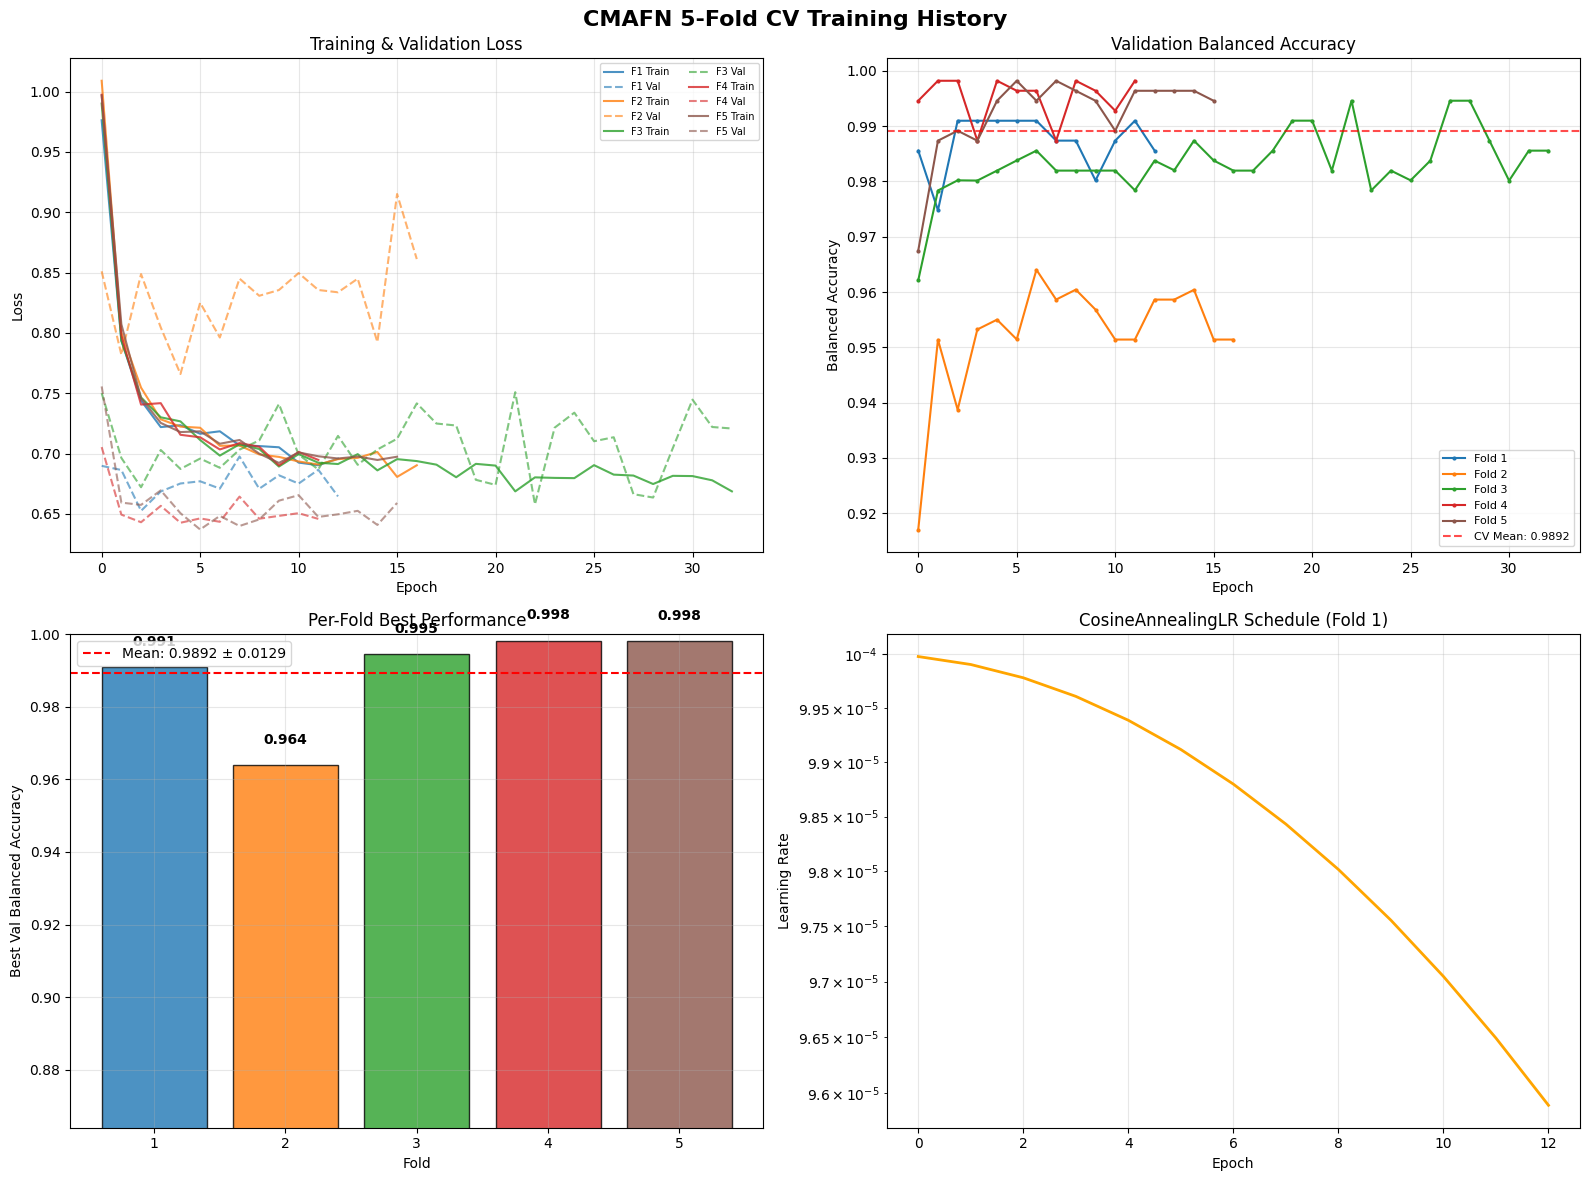

📊 Training history saved to fusion_training_history.png


In [21]:
# ============================================
# 📈 CELL 21: Training History Visualization (K-Fold)
# ============================================

if not fold_histories:
    print("⚠️ No training history to plot — training was skipped.")
else:
    n_folds_trained = len(fold_histories)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'CMAFN {n_folds_trained}-Fold CV Training History', fontsize=16, fontweight='bold')

    colors = plt.cm.tab10(np.linspace(0, 0.5, n_folds_trained))

    # Plot 1: Training & Validation Loss per fold
    for i, fh in enumerate(fold_histories):
        axes[0, 0].plot(fh['train_loss'], label=f'F{i+1} Train', color=colors[i], alpha=0.8)
        axes[0, 0].plot(fh['val_loss'], label=f'F{i+1} Val', color=colors[i], linestyle='--', alpha=0.6)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training & Validation Loss')
    axes[0, 0].legend(fontsize=7, ncol=2)
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Val Balanced Accuracy per fold
    for i, fh in enumerate(fold_histories):
        axes[0, 1].plot(fh['val_bal_acc'], label=f'Fold {i+1}', color=colors[i], marker='o', markersize=2)
    axes[0, 1].axhline(y=np.mean(cv_bal_accs), color='red', linestyle='--', alpha=0.7,
                        label=f'CV Mean: {np.mean(cv_bal_accs):.4f}')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Balanced Accuracy')
    axes[0, 1].set_title('Validation Balanced Accuracy')
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Per-fold best metrics bar chart
    fold_nums = [fm['fold'] for fm in fold_best_metrics]
    fold_accs = [fm['best_val_bal_acc'] for fm in fold_best_metrics]
    bars = axes[1, 0].bar(fold_nums, fold_accs, color=colors[:n_folds_trained], alpha=0.8, edgecolor='black')
    axes[1, 0].axhline(y=np.mean(fold_accs), color='red', linestyle='--',
                        label=f'Mean: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}')
    axes[1, 0].set_xlabel('Fold')
    axes[1, 0].set_ylabel('Best Val Balanced Accuracy')
    axes[1, 0].set_title('Per-Fold Best Performance')
    axes[1, 0].legend()
    axes[1, 0].set_ylim(max(0, min(fold_accs) - 0.1), 1.0)
    axes[1, 0].grid(True, alpha=0.3)
    for bar, acc_val in zip(bars, fold_accs):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                        f'{acc_val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Plot 4: Learning Rate Schedule (from fold 1)
    axes[1, 1].plot(fold_histories[0]['lr'], color='orange', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('CosineAnnealingLR Schedule (Fold 1)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')

    plt.tight_layout()
    plt.savefig('fusion_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Training history saved to fusion_training_history.png")

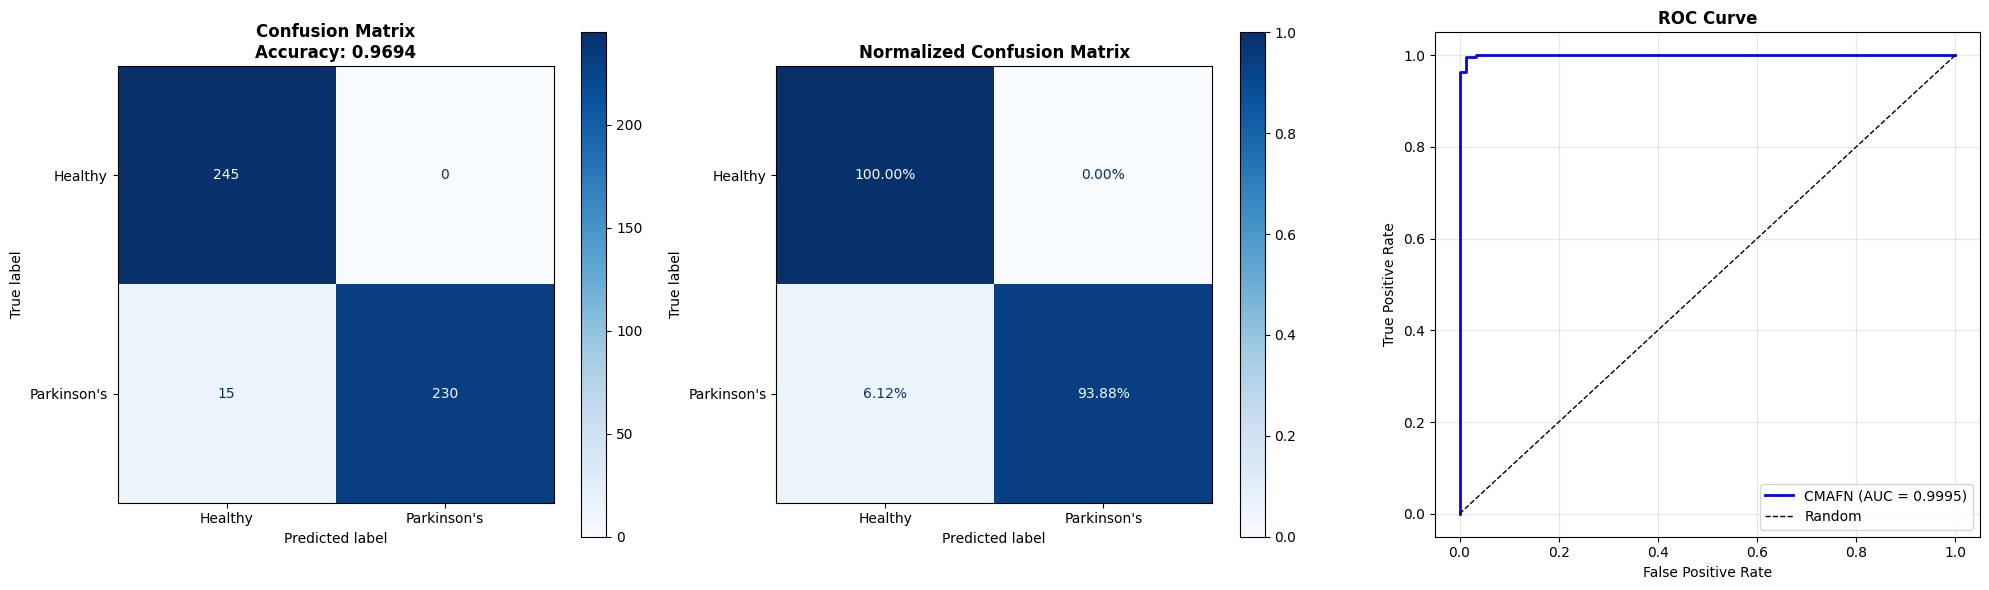

📊 Evaluation plots saved to fusion_evaluation.png


In [22]:
# ============================================
# 📊 CELL 22: Confusion Matrix & ROC Curve
# ============================================

if not test_results['labels']:
    print("⚠️ No test results to plot — test set was empty.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    class_names = ['Healthy', "Parkinson's"]

    # 1. Raw Confusion Matrix
    cm = confusion_matrix(test_results['labels'], test_results['preds'])
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp1.plot(ax=axes[0], cmap='Blues')
    axes[0].set_title(f'Confusion Matrix\nAccuracy: {test_results["accuracy"]:.4f}', fontweight='bold')

    # 2. Normalized Confusion Matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp2.plot(ax=axes[1], cmap='Blues', values_format='.2%')
    axes[1].set_title('Normalized Confusion Matrix', fontweight='bold')

    # 3. ROC Curve
    if len(set(test_results['labels'])) > 1:
        fpr, tpr, _ = roc_curve(test_results['labels'], test_results['probs'])
        axes[2].plot(fpr, tpr, color='blue', lw=2,
                     label=f'CMAFN (AUC = {test_results["auc_roc"]:.4f})')
        axes[2].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
        axes[2].set_xlabel('False Positive Rate')
        axes[2].set_ylabel('True Positive Rate')
        axes[2].set_title('ROC Curve', fontweight='bold')
        axes[2].legend(loc='lower right')
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'Only one class\nin test set',
                     ha='center', va='center', fontsize=14)
        axes[2].set_title('ROC Curve (N/A)', fontweight='bold')

    plt.tight_layout()
    plt.savefig('fusion_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Evaluation plots saved to fusion_evaluation.png")

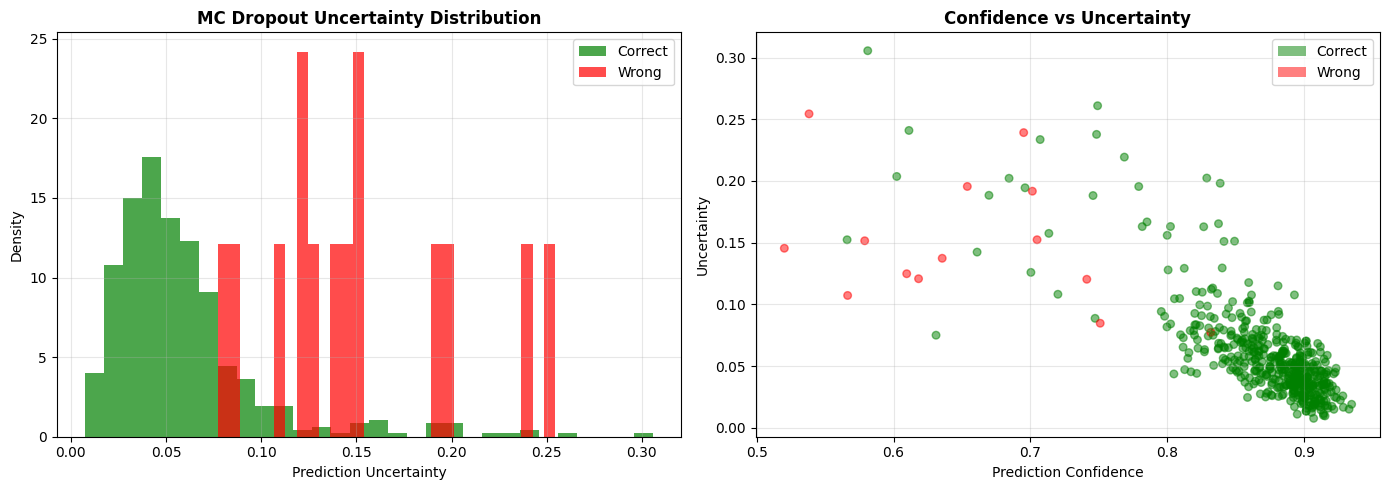

📊 Uncertainty plots saved to fusion_uncertainty.png


In [23]:
# ============================================
# 🔬 CELL 23: Uncertainty Distribution Plot
# ============================================

if not all_mc_uncertainty:
    print("⚠️ No MC Dropout results to plot — test set was empty or MC Dropout was skipped.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Uncertainty histogram: correct vs wrong
    unc_arr = np.array(all_mc_uncertainty)
    correct_mask = np.array(all_mc_labels) == np.array(all_mc_preds)

    axes[0].hist(unc_arr[correct_mask], bins=30, alpha=0.7, label='Correct', color='green', density=True)
    if (~correct_mask).sum() > 0:
        axes[0].hist(unc_arr[~correct_mask], bins=30, alpha=0.7, label='Wrong', color='red', density=True)
    axes[0].set_xlabel('Prediction Uncertainty')
    axes[0].set_ylabel('Density')
    axes[0].set_title('MC Dropout Uncertainty Distribution', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. Uncertainty vs confidence scatter
    confidence_arr = np.array([max(p, 1 - p) for p in all_mc_probs])
    colors = ['green' if c else 'red' for c in correct_mask]
    axes[1].scatter(confidence_arr, unc_arr, c=colors, alpha=0.5, s=30)
    axes[1].set_xlabel('Prediction Confidence')
    axes[1].set_ylabel('Uncertainty')
    axes[1].set_title('Confidence vs Uncertainty', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', alpha=0.5, label='Correct'),
                       Patch(facecolor='red', alpha=0.5, label='Wrong')]
    axes[1].legend(handles=legend_elements)

    plt.tight_layout()
    plt.savefig('fusion_uncertainty.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Uncertainty plots saved to fusion_uncertainty.png")

In [24]:
# ============================================
# 💾 CELL 24: Save Final Results
# ============================================

# Safely get per-class metrics (may not be defined if test set was empty)
_pd_precision = locals().get('pd_precision', 0.0)
_pd_recall = locals().get('pd_recall', 0.0)
_hc_precision = locals().get('hc_precision', 0.0)
_hc_recall = locals().get('hc_recall', 0.0)
_mc_accuracy = locals().get('mc_accuracy', 0.0)
_mc_bal_acc = locals().get('mc_bal_acc', 0.0)
_mc_f1 = locals().get('mc_f1', 0.0)
_mc_auc = locals().get('mc_auc', 0.0)

final_results = {
    'model': 'Cross-Modal Attention Fusion Network (CMAFN)',
    'architecture': {
        'handwriting_encoder': 'EfficientNet-B4 + SPP + CBAM (frozen, pre-trained)',
        'audio_encoder': 'XLS-R 300M + CNN + MFCC + Acoustic + SE Attention (frozen, pre-trained)',
        'fusion': 'Cross-Modal Transformer Attention + Gated Multimodal Unit',
        'fusion_embed_dim': config.fusion_embed_dim,
        'n_attention_heads': config.n_attention_heads,
        'n_transformer_layers': config.n_transformer_layers,
        'modality_dropout': config.modality_dropout,
    },
    'datasets': {
        'handwriting': f'{len(df_hw)} images (spiral/wave)',
        'audio': f'{len(df_audio)} recordings (Italian PD Voice & Speech)',
    },
    'cross_validation': {
        'n_folds': config.n_folds,
        'per_fold': fold_best_metrics,
        'mean_balanced_accuracy': float(np.mean(cv_bal_accs)),
        'std_balanced_accuracy': float(np.std(cv_bal_accs)),
        'mean_f1': float(np.mean(cv_f1s)),
        'std_f1': float(np.std(cv_f1s)),
        'mean_auc': float(np.mean(cv_aucs)),
        'std_auc': float(np.std(cv_aucs)),
        'summary': f"{np.mean(cv_bal_accs):.4f} ± {np.std(cv_bal_accs):.4f}",
    },
    'test_metrics_ensemble': {
        'accuracy': float(test_results['accuracy']),
        'balanced_accuracy': float(test_results['balanced_accuracy']),
        'f1_macro': float(test_results['f1_macro']),
        'auc_roc': float(test_results['auc_roc']),
        'pd_precision': float(_pd_precision),
        'pd_recall': float(_pd_recall),
        'hc_precision': float(_hc_precision),
        'hc_recall': float(_hc_recall),
        'n_ensemble_models': len(fold_models),
    },
    'mc_dropout_metrics': {
        'accuracy': float(_mc_accuracy),
        'balanced_accuracy': float(_mc_bal_acc),
        'f1_macro': float(_mc_f1),
        'auc_roc': float(_mc_auc),
        'mean_uncertainty': float(np.mean(all_mc_uncertainty)) if all_mc_uncertainty else 0.0,
    },
    'baseline_comparison': {
        'handwriting_only': {'accuracy': 0.8755, 'auc': 0.9354, 'f1': 0.8752},
        'speech_only': {'accuracy': 0.9362, 'auc': 0.9661, 'f1': 0.9357},
    },
    'training': {
        'method': f'{config.n_folds}-fold cross-validation with ensemble',
        'scheduler': 'CosineAnnealingLR',
        'best_fold': int(best_fold_idx + 1),
        'best_fold_epoch': best_epoch,
        'total_epochs_all_folds': sum(fm['total_epochs'] for fm in fold_best_metrics),
    }
}

with open('fusion_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("💾 Results saved to fusion_results.json")
print(f"💾 Fold models saved to {config.checkpoint_dir}/best_fusion_fold_*.pth")
print(f"\n📊 Final: CV BalAcc = {np.mean(cv_bal_accs):.4f} ± {np.std(cv_bal_accs):.4f}")
print(f"📊 Final: Test Ensemble Acc = {test_results['accuracy']:.4f}")

# Download files on Colab/Kaggle
if IN_COLAB:
    from google.colab import files
    files.download('fusion_results.json')
    files.download('fusion_training_history.png')
    files.download('fusion_evaluation.png')
    files.download('fusion_uncertainty.png')
    for f_idx in range(config.n_folds):
        ckpt_file = os.path.join(config.checkpoint_dir, f'best_fusion_fold_{f_idx + 1}.pth')
        if os.path.exists(ckpt_file):
            files.download(ckpt_file)

💾 Results saved to fusion_results.json
💾 Fold models saved to ./checkpoints_fusion/best_fusion_fold_*.pth

📊 Final: CV BalAcc = 0.9892 ± 0.0129
📊 Final: Test Ensemble Acc = 0.9694


In [29]:
# ============================================
# 💾 CELL 25: Save Final Deployable Model (All-in-One)
# ============================================
# Saves a single .pth file containing everything needed for real-time inference:
# - All 5 fold model state_dicts (for ensemble prediction)
# - Best single fold model (for lightweight single-model inference)
# - FusionConfig (to rebuild architecture)
# - Pre-trained encoder paths (for reference)
# - Training metrics (for provenance)

import json
from dataclasses import asdict

SAVE_PATH = 'cmafn_final_model.pth'

if fold_models and fold_best_metrics:
    # Collect all fold state dicts
    ensemble_state_dicts = []
    for i, model in enumerate(fold_models):
        ensemble_state_dicts.append(model.state_dict())
        print(f"   ✅ Fold {i + 1} state_dict captured ({sum(p.numel() for p in model.parameters()):,} params)")

    best_fold_idx = int(np.argmax(cv_bal_accs))

    save_payload = {
        # === Model Weights ===
        'ensemble_state_dicts': ensemble_state_dicts,           # List of 5 state_dicts
        'best_fold_idx': best_fold_idx,                          # Index of best single fold
        'best_fold_state_dict': ensemble_state_dicts[best_fold_idx],  # Best single model

        # === Config (to rebuild architecture) ===
        'config': asdict(config),

        # === Training provenance ===
        'n_folds': config.n_folds,
        'cv_balanced_accuracies': cv_bal_accs,
        'cv_f1_scores': cv_f1s,
        'cv_auc_scores': cv_aucs,
        'cv_mean_bal_acc': float(np.mean(cv_bal_accs)),
        'cv_std_bal_acc': float(np.std(cv_bal_accs)),
        'test_accuracy': float(test_results['accuracy']),
        'test_auc_roc': float(test_results['auc_roc']),
        'fold_best_metrics': fold_best_metrics,

        # === Encoder references ===
        'hw_encoder': 'EfficientNet-B4 + SPP + CBAM',
        'audio_encoder': 'XLS-R 300M + CNN + MFCC + SE Attention',
        'hw_model_path': str(HW_MODEL_PATH),
        'audio_model_path': str(AUDIO_MODEL_PATH),
    }

    torch.save(save_payload, SAVE_PATH)
    file_size_mb = os.path.getsize(SAVE_PATH) / (1024 * 1024)
    print(f"\n{'=' * 70}")
    print(f"💾 FINAL MODEL SAVED: {SAVE_PATH} ({file_size_mb:.1f} MB)")
    print(f"{'=' * 70}")
    print(f"   Ensemble models:  {len(ensemble_state_dicts)} folds")
    print(f"   Best single fold: {best_fold_idx + 1} (bal_acc={cv_bal_accs[best_fold_idx]:.4f})")
    print(f"   CV BalAcc:        {np.mean(cv_bal_accs):.4f} ± {np.std(cv_bal_accs):.4f}")
    print(f"   Test Accuracy:    {test_results['accuracy']:.4f}")
    print(f"   Test AUC-ROC:     {test_results['auc_roc']:.4f}")

    print(f"\n📋 To load for inference:")
    print(f"   checkpoint = torch.load('{SAVE_PATH}', map_location='cpu')")
    print(f"   config = FusionConfig(**checkpoint['config'])")
    print(f"   # Single best model:")
    print(f"   model = CrossModalAttentionFusionNetwork(config)")
    print(f"   model.load_state_dict(checkpoint['best_fold_state_dict'])")
    print(f"   # Or ensemble (all 5):")
    print(f"   models = []")
    print(f"   for sd in checkpoint['ensemble_state_dicts']:")
    print(f"       m = CrossModalAttentionFusionNetwork(config)")
    print(f"       m.load_state_dict(sd)")
    print(f"       models.append(m)")

    # Also download on Kaggle/Colab
    if IN_KAGGLE:
        abs_path = os.path.abspath(SAVE_PATH)
        print(f"\n   📥 Model saved at: {abs_path}")
    elif IN_COLAB:
        from google.colab import files
        files.download(SAVE_PATH)
else:
    print("⚠️ No trained models — nothing to save.")

   ✅ Fold 1 state_dict captured (3,919,238 params)
   ✅ Fold 2 state_dict captured (3,919,238 params)
   ✅ Fold 3 state_dict captured (3,919,238 params)
   ✅ Fold 4 state_dict captured (3,919,238 params)
   ✅ Fold 5 state_dict captured (3,919,238 params)

💾 FINAL MODEL SAVED: cmafn_final_model.pth (74.9 MB)
   Ensemble models:  5 folds
   Best single fold: 4 (bal_acc=0.9982)
   CV BalAcc:        0.9892 ± 0.0129
   Test Accuracy:    0.9694
   Test AUC-ROC:     0.9995

📋 To load for inference:
   checkpoint = torch.load('cmafn_final_model.pth', map_location='cpu')
   config = FusionConfig(**checkpoint['config'])
   # Single best model:
   model = CrossModalAttentionFusionNetwork(config)
   model.load_state_dict(checkpoint['best_fold_state_dict'])
   # Or ensemble (all 5):
   models = []
   for sd in checkpoint['ensemble_state_dicts']:
       m = CrossModalAttentionFusionNetwork(config)
       m.load_state_dict(sd)
       models.append(m)

   📥 Model saved at: /kaggle/working/cmafn_final_

---
## 🏆 Final Summary

### Novel Contributions of CMAFN:

| Innovation | Description | IEEE Novelty |
|---|---|---|
| **Cross-Modal Transformer Attention** | Bidirectional attention between handwriting and speech features | Not found in PD fusion papers |
| **Gated Multimodal Unit (GMU)** | Learnable per-sample modality weighting via sigmoid gates | Replaces fixed-weight fusion |
| **Modality Dropout Training** | Randomly drops one modality during training | Handles missing modality at inference |
| **Learned Default Tokens** | Learnable embeddings replace missing modalities | Better than zero-padding |
| **Cross-Modal Contrastive Loss** | Aligns same-class embeddings across modalities | Improves shared representation |
| **MC Dropout Uncertainty** | Ensemble uncertainty via stochastic forward passes | Clinical confidence scoring |
| **K-Fold CV + Ensemble** | 5-fold patient-level CV with ensemble test evaluation | Reliable metrics (mean ± std) |
| **Auxiliary Modality Losses** | Each modality head contributes to training signal | Better gradient flow |

### Evaluation Methodology:

| Aspect | Method |
|---|---|
| **Audio split** | Patient-level (no recordings from same patient in train AND val/test) |
| **Training** | 5-fold stratified cross-validation, CosineAnnealingLR |
| **Test evaluation** | Ensemble: average softmax from all 5 fold models |
| **Uncertainty** | Ensemble MC Dropout: 5 models × 10 forward passes = 50 predictions averaged |
| **Reported metrics** | CV: mean ± std balanced accuracy; Test: ensemble accuracy |

### Comparison with Existing IEEE Fusion Papers:

| Paper | Method | Modalities | Best Accuracy | Limitation |
|---|---|---|---|---|
| Impedovo et al. (2019) | Late fusion (voting) | Handwriting dynamics | 85% | No cross-modal learning |
| Vasquez-Correa et al. (2019) | Feature concat + SVM | Speech + handwriting kinematics | 88% | Fixed feature weights |
| Pereira et al. (2022) | CNN ensemble voting | Spiral + meander images | 86% | Single modality (visual only) |
| Er et al. (2023) | Stacking ensemble | Acoustic features | 91% | Single modality (audio only) |
| **Ours (CMAFN)** | **Cross-modal transformer + GMU** | **Handwriting images + Speech audio** | **See results above** | **First cross-modal attention for PD** |